<img src=../figures/Brown_logo.svg width=50%>

# SHORT COURSE

## Data-Driven Design & Analyses of Structures & Materials (3dasm)


### Lecture 1: Introduction to the Bayesian Perspective of Machine Learning

---

Miguel A. Bessa | <a href = "mailto: miguel_bessa@brown.edu">miguel_bessa@brown.edu</a>  | Associate Professor

### Q1. What do you hope to gain from this short course?

In [1]:
from IPython.display import IFrame, display, HTML
display(HTML('''<div style="display: flex; align-items: flex-start; gap: 20px;">
    <div style="text-align: center;"> <img src="figures/slido_qr_code.png" width="200">
    <p><b>Scan to answer</b></p> </div>
    <iframe src="https://app.sli.do/event/vMxC77fHSUt38s6Dx6hgKG" width="1200" height="650"
    frameBorder="0" allow="clipboard-write"></iframe> </div>'''))

## **OPTION 1**. Run this notebook **locally in your computer**:

This is **only possible if you correctly installed all necessary packages** in the '3dasm' virtual environment.

* Installation instructions are available in the [course home page](https://github.com/bessagroup/3dasm_course).

If you have all packages already installed:

1. Open a (mamba) command window and load jupyter notebook (it will open in your internet browser):
```
jupyter notebook
``` 
2. Open notebook (*3dasm_course/Lectures/Lecture1/3dasm_Lecture1.ipynb*) and choose the '3dasm' kernel.

You're all set!

## **OPTION 2**. Use **Google's Colab** (no installation required, but times out if idle):

1. go to https://colab.research.google.com
2. login
3. File > Open notebook
4. click on Github (no need to login or authorize anything)
5. paste the git link: https://github.com/bessagroup/3dasm_course
6. click search and then click on the notebook (*3dasm_course/Lectures/short_course/d3_summer_school.ipynb*)

In [2]:
# Basic plotting tools needed in Python.

import matplotlib.pyplot as plt # import plotting tools to create figures
import numpy as np # import numpy to handle a lot of things!
from IPython.display import display, Math # to print with Latex math

%config InlineBackend.figure_format = "retina" # render higher resolution images in the notebook
plt.rcParams["figure.figsize"] = (8,4) # rescale figure size appropriately for slides

## Outline for this lecture

* **Part I**: Introduction to Bayesian machine learning
    - Random variables and the Gaussian distribution
    - Creating a probabilistic model
    - Bayes' rule and computing the Likelihood

* **Part II**: From Posterior to Predictions
    - The Posterior Predictive Distribution (PPD)
    - Multivariate Gaussian distributions
    - Covariance and conditioning

* **Part III**: Machine learning without going fully Bayesian (~50 min)
    - Point estimates: approximating the posterior as a Dirac delta
    - Maximum A Posteriori (MAP) and Maximum Likelihood Estimation (MLE)

---

**For more details**: See Lectures 1-8 of the full course in this repo.

# Part I: Introduction to Bayesian machine learning

- Short introducing to machine learning from a probabilistic perspective (Bayesian machine learning).
    - A machine learning model is completely defined by (1) **observation distribution** and (2) **prior distribution**.
    - The goal of a machine learning model is to get the **posterior predictive distribution (PPD)**
    - Analytical solution for simple 1D example: the car stopping distance problem with 1 hidden variable

## The car stopping distance problem

<img src="../figures/reaction-braking-stopping.svg" title="Car stopping distance" width="50%" align="right">

<br></br>
Car stopping distance ${\color{red}y}$ as a function of its velocity ${\color{green}x}$ before it starts braking:

${\color{red}y} = {\color{blue}z} x + \frac{1}{2\mu g} {\color{green}x}^2 = {\color{blue}z} x + 0.1 {\color{green}x}^2$

- ${\color{blue}z}$ is the driver's reaction time (in seconds)
- $\mu$ is the road/tires coefficient of friction (assume $\mu=0.5$)
- $g$ is the acceleration of gravity (assume $g=10$ m/s$^2$).

<div class="alert alert-block alert-info"><b>Remark: Jupyter Notebooks can contain <font color=red>notes</font> not shown when in presentation mode. (See below)</div>

## The car stopping distance problem

### How to obtain this formula?

$y = d_r + d_{b}$

where $d_r$ is the reaction distance, and $d_b$ is the braking distance.

### Reaction distance $d_r$

$d_r = z x$

with $z$ being the driver's reaction time, and $x$ being the velocity of the car at the start of braking.

## The car stopping distance problem

### Braking distance $d_b$

Kinetic energy of moving car:

$E = \frac{1}{2}m x^2$ &nbsp; &nbsp; &nbsp; where $m$ is the car mass.

Work done by braking:

$W = \mu m g d_b$ &nbsp; &nbsp; &nbsp; where $\mu$ is the coefficient of friction between the road and the tire, $g$ is the acceleration of gravity, and $d_b$ is the car braking distance.

The braking distance follows from $E=W$:

$d_b = \frac{1}{2\mu g}x^2$

Therefore, if we add the reacting distance $d_r$ to the braking distance $d_b$ we get the stopping distance $y$:

$$y = d_r + d_b = z x + \frac{1}{2\mu g} x^2$$

## The car stopping distance problem

<img src="../figures/reaction-braking-stopping.svg" title="Car stopping distance" width="25%" align="right">

$y = {\color{blue}z} x + 0.1 x^2$

The driver's reaction time ${\color{blue}z}$ is a **random variable (rv)**

* Every driver has its own reaction time $z$

* Assume we know the distribution associated to $z$ is Gaussian with **mean** $\mu_z=1.5$ seconds and **variance** $\sigma_z^2=0.5^2$ seconds$^2$

$$
z \sim \mathcal{N}(\mu_z=1.5,\sigma_z^2=0.5^2)
$$

where $\sim$ means "sampled from", and $\mathcal{N}$ indicates a Gaussian **probability density function (pdf)**

## Univariate Gaussian <a title="probability density function">pdf</a> 

$$
    p(z) = \mathcal{N}(z | \mu_z, \sigma_z^2) = \frac{1}{\sqrt{2\pi\sigma_z^2}}e^{-\frac{1}{2\sigma_z^2}(z - \mu_z)^2}
$$

The output of this expression is the **PROBABILITY DENSITY** of $z$ **given** (or conditioned to) a particular $\mu_z$ and $\sigma_z^2$.

* **Important**: Probability Density $\neq$ Probability

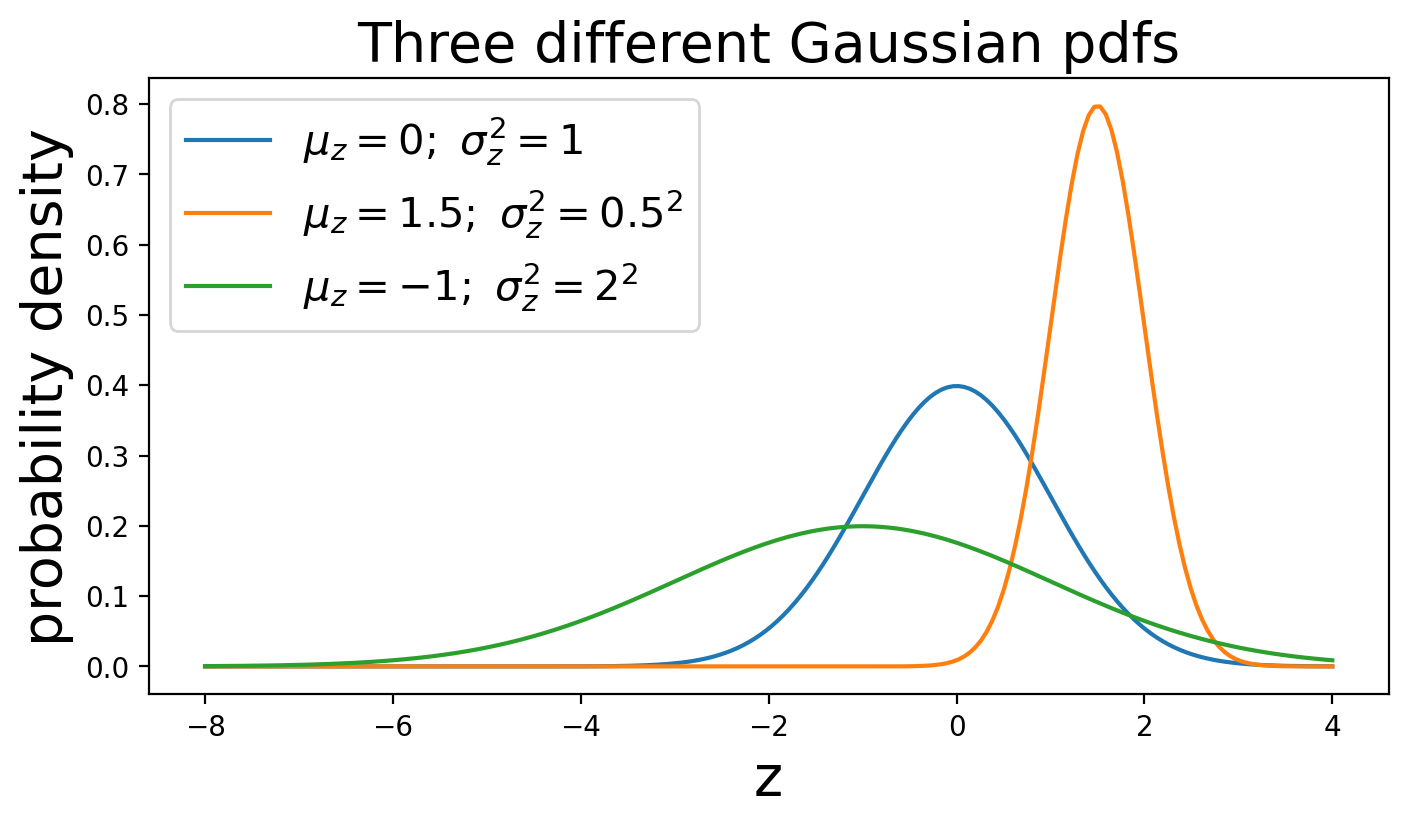

In [3]:
def norm_pdf(z, mu_z, sigma_z2): return 1/np.sqrt(2*np.pi*sigma_z2)*np.exp(-(z-mu_z)**2/(2*sigma_z2))
zrange = np.linspace(-8, 4, 200) # create a list of 200 z points between z=-8 and z=4
fig, ax = plt.subplots() # create a plot
ax.plot(zrange, norm_pdf(zrange, 0, 1), label=r"$\mu_z=0; \ \sigma_z^2=1$") # plot norm_pdf(z|0,1)
ax.plot(zrange, norm_pdf(zrange, 1.5, 0.5**2), label=r"$\mu_z=1.5; \ \sigma_z^2=0.5^2$") # plot norm_pdf(z|1.5,0.5^2)
ax.plot(zrange, norm_pdf(zrange, -1, 2**2), label=r"$\mu_z=-1; \ \sigma_z^2=2^2$") # plot norm_pdf(z|-1,2^2)
ax.set_xlabel("z", fontsize=20) # create x-axis label with font size 20
ax.set_ylabel("probability density", fontsize=20) # create y-axis label with font size 20
ax.legend(fontsize=15) # create legend with font size 15
ax.set_title("Three different Gaussian pdfs", fontsize=20); # create title with font size 20

## Simplifying further the car stopping distance problem (constant velocity)

<img src="../figures/reaction-braking-stopping.svg" title="Car stopping distance" width="25%" align="right">
<br></br>
Let's now consider the case of constant velocity $x=75$ m/s:

${\color{red}y} = {\color{blue}z}\cdot 75 + 0.1\cdot 75^2 = 75 {\color{blue}z} + 562.5$

- ${\color{red}y}$ is the **output**: the car stopping distance (in meters)
- ${\color{blue}z}$ is a hidden variable: an <a title="random variable">rv</a> representing the driver's reaction time (in seconds)

where $z \sim \mathcal{N}(\mu_z=1.5,\sigma_z^2=0.5^2)$

In [4]:
# This cell is hidden during presentation. It's just to define a function to plot the governing model of
# the car stopping distance problem. Defining a function that creates a plot allows to repeatedly run
# this function on cells used in this notebook.
def car_fig(ax):
    x = np.linspace(3, 83, 1000)
    mu_z = 1.5; sigma_z = 0.5;  # parameters of the "true" p(z)
    mu_y = mu_z*x + 0.1*x**2 # From Homework of Lecture 4
    sigma_y = np.sqrt( (x*sigma_z)**2 ) # From Homework of Lecture 4
    ax.set_xlabel("x (m/s)", fontsize=20) # create x-axis label with font size 20
    ax.set_ylabel("y (m)", fontsize=20) # create y-axis label with font size 20
    ax.set_title("Car stopping distance problem", fontsize=20); # create title with font size 20
    ax.plot(x, mu_y, 'k:', label="Governing model $\mu_y$")
    ax.fill_between(x, mu_y - 1.9600 * sigma_y,
                    mu_y + 1.9600 * sigma_y,
                    color='k', alpha=0.2,
                    label='95% confidence interval ($\mu_y \pm 1.96\sigma_y$)') # plot 95% credence interval
    ax.legend(fontsize=15)

In [5]:
# This cell is also hidden during presentation.
from scipy.stats import norm # import the normal dist, as we learned before!
def samples_y(N_samples,x): # observations/measurements/samples for car stop. dist. prob.
    mu_z = 1.5; sigma_z = 0.5;
    samples_z = norm.rvs(mu_z, sigma_z, size=N_samples) # randomly draw samples from the normal dist.
    samples_y = samples_z*x + 0.1*x**2 # compute the stopping distance for samples of z
    return samples_y # return samples of y

Empirical mean[y] is 674.5869651002831 (real mean[y]=675)
Empirical std[y] is 39.48626195243003 (real std[y]=37.5)


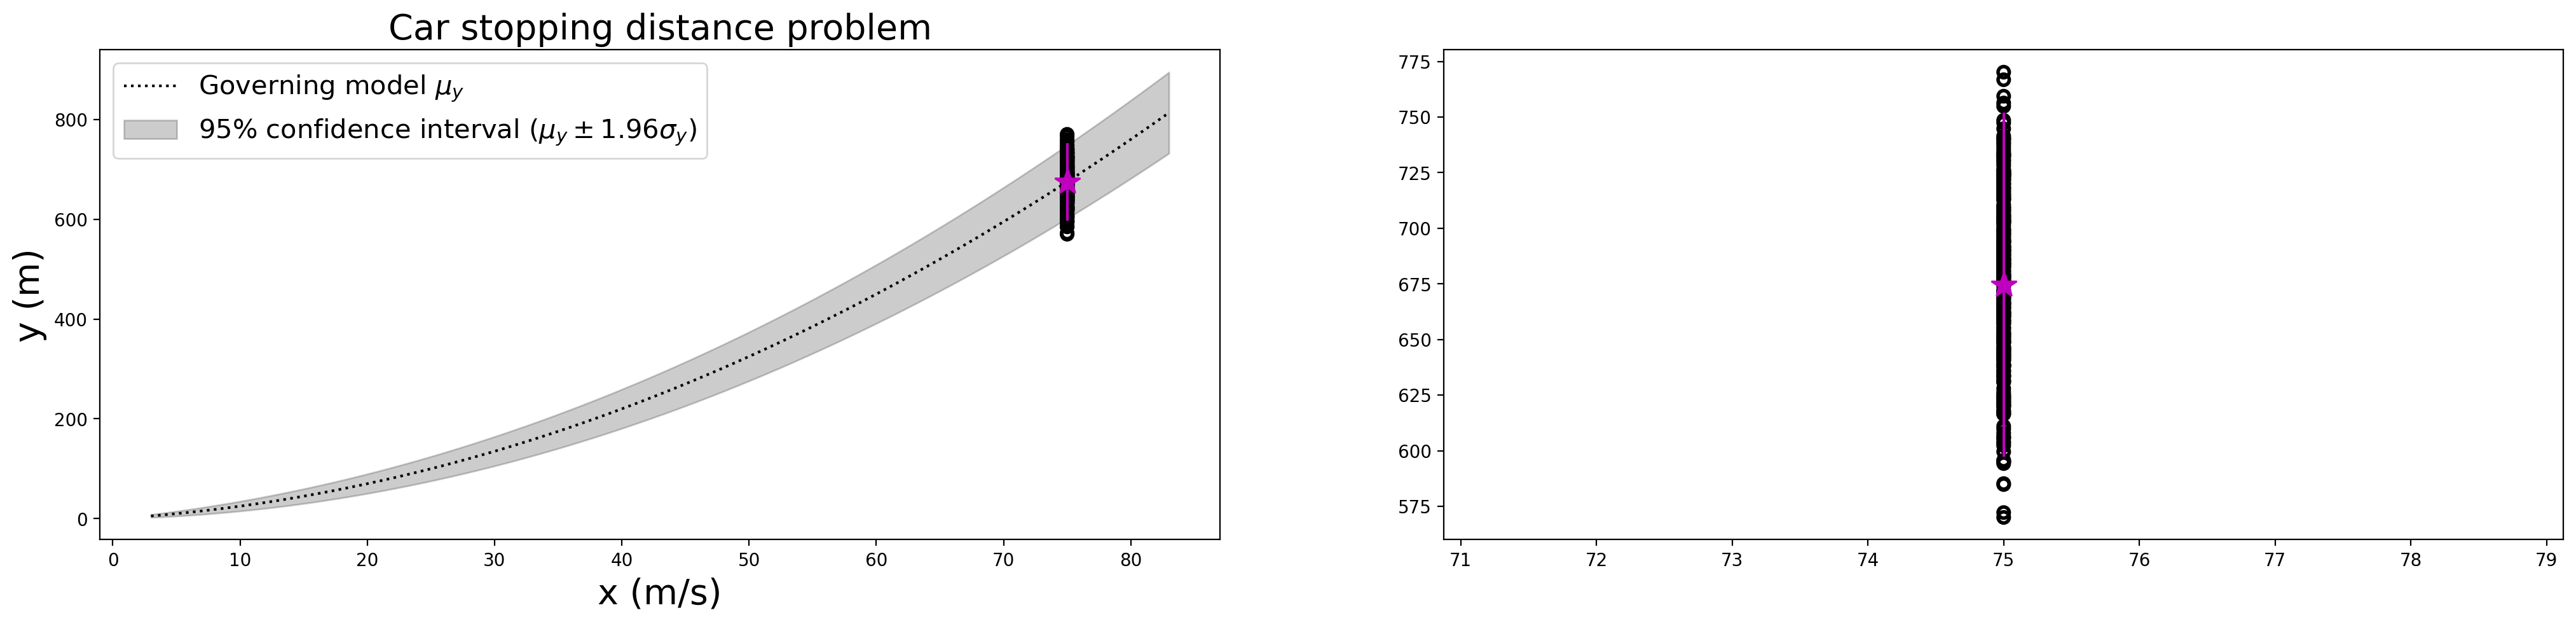

In [6]:
# vvvvvvvvvvv this is just a trick so that we can run this cell multiple times vvvvvvvvvvv
fig_car_new, ax_car_new = plt.subplots(1,2); plt.close() # create figure and close it
if fig_car_new.get_axes():
    del ax_car_new; del fig_car_new # delete figure and axes if they exist
    fig_car_new, ax_car_new = plt.subplots(1,2) # create them again
# ^^^^^^^^^^^ end of the trick ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
N_samples = 300 # CHANGE THIS NUMBER AND RE-RUN THE CELL
x = 75; empirical_y = samples_y(N_samples, x); # Empirical measurements of N_samples at x=75
empirical_mu_y = np.mean(empirical_y); empirical_sigma_y = np.std(empirical_y); # empirical mean and std
car_fig(ax_car_new[0]) # a function I created to include the background plot of the governing model
for i in range(2): # create two plots (one is zooming in on the error bar)
    ax_car_new[i].errorbar(x , empirical_mu_y,yerr=1.96*empirical_sigma_y, fmt='m*', markersize=15);
    ax_car_new[i].scatter(x*np.ones_like(empirical_y),empirical_y, s=40,
                          facecolors='none', edgecolors='k', linewidths=2.0)
print("Empirical mean[y] is",empirical_mu_y, "(real mean[y]=675)")
print("Empirical std[y] is",empirical_sigma_y,"(real std[y]=37.5)")
fig_car_new.set_size_inches(25, 5) # scale figure to be wider (since there are 2 subplots)

### Car stopping distance problem without knowing the reaction time

<img src="../figures/reaction-braking-stopping.svg" title="Car stopping distance" width="25%" align="right">

For a constant velocity of the car, $x=75$ m/s, we want to be able to predict the stopping distance $y$.

We suspect that $y$ depends on a **hidden** (unobserved) variable $z$, which is the reaction time of the driver. We also know that $z$ has to be a random variable because the same person never takes exactly the same time to react.

- This implies that the car stopping distance $y$ is also a random variable, i.e., each new $y^*$ that we observe arises from a distribution: $p(y^*)$.

But if we don't know $z$ and we can't measure it, then how can we predict $p(y^*)$?

- From measurements of $y$, i.e. from data $\to$ $\mathbf{y} = \mathcal{D}_y$.

| $y_i$ (m) |
| ---- |
| 601.5 |
| 705.9 |
| 693.8 |
| ...   |
| 711.3 |

where the data $\mathcal{D}_y$ can be a Pandas dataframe with $N$ data points ($N$ rows).

Therefore, the goal is to use measurements of $y$ to determine the distribution:

$$
\require{color}
{\color{orange}p(y^*|y=\mathcal{D}_y)}
$$

which is called the **posterior predictive distribution** (PPD).

If we collect infinite samples of $y$, then we determine this distribution exactly (problem solved!).

**Problem 1**: What can we do when we cannot collect enough data samples to make a good estimation of the PPD ${\color{orange}p(y^*|y=\mathcal{D}_y)}$?

- **Solution**:
    1. Create a model about how $y$ depends on $z$, i.e. how $y$ depends on what we don't know.

    2. Then, consider all possible values of $z$ because they are what makes $y$ assume a distribution!

**Problem 2**: But $z$ is a random variable... It can take many values (actually, an infinite number of values)! No reaction time is *exactly* the same. Thus, $z$ also comes from a distribution!

- **Solution**: create a model for the distribution of $z$.

**Conclusion**: estimating the PPD of $y^*$ after observing some data $\mathcal{D}_y$ is only possible by creating a model that depends on what we **do not know** ($z$), and considering all possible values that $z$ can get:

$$\require{color}
{\color{orange}p(y^*|y=\mathcal{D}_y)} = \int {\color{blue}p(y^*|z)} {\color{green}p(z|y=\mathcal{D}_y)} dz
$$

Therefore, we need to define two terms:

- ${\color{blue}p(y^*|z)}$: the **observation distribution** (dependence of $y^*$ on $z$)

- ${\color{green}p(z|y=\mathcal{D}_y)}$: the **posterior** (dependence of $z$ on the observed data).

Unfortunately, the posterior cannot be defined or assumed because **we do not observe** $z$ from the data.

That's where the Bayes rule comes to the rescue. When no data is observed, the Bayes rule is written as:

$\require{color}$
$$
{\color{green}p(z|y)} = \frac{ {\color{blue}p(y|z)}{\color{red}p(z)} } {p(y)}
$$

* ${\color{red}p(z)}$ is the **prior distribution** $\to$ our model for the distribution of $z$, without any observation!
* ${\color{blue}p(y|z)}$ is the **observation distribution** $\to$ our model for the distribution of $y$ given $z$
* $p(y)$ is the **marginal distribution** $\to$ normalization constant: $p(y) = \int {\color{blue}p(y|z)} {\color{red}p(z)} dz$
* ${\color{green}p(z|y)}$ is the **posterior distribution** $\to$ what we want to find because we cannot observe it nor assume it

### Creating a model for the car stopping distance problem

<img src="../figures/reaction-braking-stopping.svg" title="Car stopping distance" width="25%" align="right">

**First**, we need to decide what distribution ${\color{blue}p(y|z)}$ we want to use for our model.

- What is the simplest distribution that we can choose?

A Gaussian distribution!

If we know our Physics, we may also know what is the average $y$ for a given average reaction time $z$. In other words, we know the expression for the mean of the Gaussian:

$$
p(y|z) = \mathcal{N}\left(y | \mu_{y|z}=w z+b, \sigma_{y|z}^2={\color{red}s}^2\right)
$$

where $w$, $b$ and $s$ are all constants that we determined in the beginning of this lecture ($w=x=75$ and $b=0.1 x^2=562.5$).

However, let's assume that we don't know enough Physics to know what the variance ${\color{red}s}^2$ is... In that case, we can assume a value (or some other analytical expression). For example, assume ${\color{red}s}^2=80^2$.

* Note: we could have assumed any other values. This is just the best model we could think of.

<img src="../figures/reaction-braking-stopping.svg" title="Car stopping distance" width="25%" align="right">

Second, we need to decide what is the prior distribution ${\color{red}p(z)}$.

As we said, when we have no clue about what the distribution of the hidden rv $z$ is, then we can use a **Uniform distribution** (a.k.a. uninformative prior).

This distribution assigns equal probability to any value of $z$ within an interval $z \in (z_{min}, z_{max})$.

$$
p(z) = \frac{1}{C_z}
$$

where $C_z = z_{max}-z_{min}$ is the **normalization constant** of the Uniform pdf, i.e. the value that guarantees that $p(z)$ integrates to one.

For the time being, we will not assume any particular values for $z_{max}$ and $z_{min}$. So, we will consider the case when $z_{max}\rightarrow +\infty$ and $z_{min}\rightarrow -\infty$. Mathematically this leads to some indefinition, but it's commonly ignored. If we had some information, we could consider some values for these bounds (e.g. $z_{min} = 0$ seconds would be the limit of the fastest reaction time that is humanly possible, and $z_{max} = 3$ seconds would be the slowest reaction time of a human being).

### Summary of our model

1. The **observation distribution**:

$$
p(y|z) = \mathcal{N}\left(y | \mu_{y|z}=w z+b, \sigma_{y|z}^2\right) = \frac{1}{C_{y|z}} \exp\left[ -\frac{1}{2\sigma_{y|z}^2}(y-\mu_{y|z})^2\right]
$$

where $C_{y|z} = \sqrt{2\pi \sigma_{y|z}^2}$ is the **normalization constant** of the Gaussian pdf, and where $\mu_{y|z}=w z+b$, with $w$, $b$ and $\sigma_{y|z}^2$ being constants.

2. The **prior distribution**: $p(z) = \frac{1}{C_z}$

#### (Almost) Every machine learning model is complete when you define the observation and prior distributions.

Once we decide on the observation distribution and the prior distribution, we become capable of making any prediction due to the amazing Bayes' rule.

## The amazing Bayes' rule: application to observed data

When data is observed $\mathcal{D}_y$, then Bayes' rule is written as:

$\require{color}$
$$
{\color{green}p(z|y=\mathcal{D}_y)} = \frac{ {\color{blue}p(y=\mathcal{D}_y|z)}{\color{red}p(z)} } {p(y=\mathcal{D}_y)}
$$

* ${\color{red}p(z)}$ is the **prior** distribution
* ${\color{blue}p(y=\mathcal{D}_y|z)}$ is the **likelihood** function
* $p(y=\mathcal{D}_y)$ is the **marginal likelihood**
* ${\color{green}p(z|y=\mathcal{D}_y)}$ is the **posterior**

We can write Bayes' rule as <font color='green'>posterior</font> $\propto$ <font color='blue'>likelihood</font> $\times$ <font color='red'>prior </font>, where we are ignoring the denominator $p(y=\mathcal{D}_y)$ because it is just a **constant** independent of the hidden variable $z$.

The Bayes' rule allows to calculate the posterior ${\color{green}p(z|y=\mathcal{D}_y)}$, which then allows to calculate what we really want: the PPD!

$$\require{color}
{\color{orange}p(y^*|y=\mathcal{D}_y)} = \int {\color{blue}p(y^*|z)} {\color{green}p(z|y=\mathcal{D}_y)} dz
$$

Let's see how to do this for this simple model (where everything can be done analytically!).

$${\color{green}p(z|y=\mathcal{D}_y)} = \frac{ {\color{blue}p(y=\mathcal{D}_y|z)}{\color{red}p(z)} } {p(y=\mathcal{D}_y)}$$

- First, we need to calculate the **likelihood** function ${\color{blue}p(y=\mathcal{D}_y|z)}$

### Likelihood for car stopping distance problem

The **likelihood** is obtained by evaluating the **observation distribution** at the data $\mathcal{D}_y$.

| $y_i$ (m) |
| ---- |
| 601.5 |
| 705.9 |
| 693.8 |
| ...   |
| 711.3 |

Noting that each observation in $\mathcal{D}_y$ is independent of each other and that they have the same distribution (**indepentent and identically distributed**: i.i.d.), then how do we calculate the likelihood?

$$
p(y=\mathcal{D}_y | z) = \prod_{i=1}^{N} p(y=y_i|z) = p(y=y_1|z)p(y=y_2|z) \cdots p(y=y_N|z)
$$

which gives the **probability density** of observing that data if using our observation distribution (which is part of our model!).

#### Calculating the likelihood

Let's calculate it:

$$
\begin{align}
p(y=\mathcal{D}_y | z) &= \prod_{i=1}^{N} p(y=y_i|z) \\
&= \prod_{i=1}^{N} \frac{1}{|w|}\frac{1}{\sqrt{2\pi \left(\frac{\sigma_{y|z}}{w}\right)^2}} \exp\left\{ -\frac{1}{2\left(\frac{\sigma_{y|z}}{w}\right)^2}\left[z-\left(\frac{y_i-b}{w}\right)\right]^2\right\} \\
&= \prod_{i=1}^{N} \frac{1}{|w|} \mathcal{N}\left(z|\mu_i, \sigma_i^2\right)
\end{align}
$$

where $\mu_i = \frac{y_i-b}{w}$ and $\sigma_i =\frac{\sigma_{y|z}}{w}$

This seems a bit daunting... I know. Do not dispair yet!

##### Product of Gaussian pdf's of the same rv $z$

It can be shown that the product of $N$ univariate Gaussian pdf's of the same rv $z$ is:

$$
\prod_{i=1}^{N} \mathcal{N}(z|\mu_i, \sigma_i^2) = C \cdot \mathcal{N}(z|\mu, \sigma^2)
$$

with mean: $\mu = \sigma^2 \left( \sum_{i=1}^{N} \frac{\mu_i}{\sigma_i^2}\right)$

variance: $\sigma^2= \frac{1}{\sum_{i=1}^{N} \frac{1}{\sigma_i^2}}$

and normalization constant: $C = \frac{1}{\left(2\pi\right)^{(N-1)/2}}\sqrt{\frac{\sigma^2}{\prod_{i=1}^N \sigma_i^2}} \exp\left[-\frac{1}{2}\left(\sum_{i=1}^{N} \frac{\mu_i^2}{\sigma_i^2} - \frac{\mu^2}{\sigma^2}\right)\right]$

Curiosity: the normalization constant $C$ is itself a Gaussian! You can see it more clearly if you consider $N=2$

Note that the normalization constant shown in the previous cell can also be written as:

$$
C = \frac{1}{\left(2\pi\right)^{(N-1)/2}}\sqrt{\frac{\sigma^2}{\prod_{i=1}^N \sigma_i^2}} \exp\left[-\frac{1}{2}\left(\sum_{i=1}^{N-1}\sum_{j=i+1}^{N} \frac{(\mu_i-\mu_j)^2}{\sigma_i^2 \sigma_j^2}\sigma^2\right)\right]
$$

Therefore, the <font color='blue'>likelihood</font> for this problem becomes:

$$
{\color{blue}p(y=\mathcal{D}_y | z)} = \frac{1}{|w|^N} \cdot C \cdot \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left[ -\frac{1}{2\sigma^2}(z-\mu)^2\right]
$$

where $\mu = \frac{w^2\sigma^2}{\sigma_{y|z}^2} \sum_{i=1}^N \mu_i$

$\sigma^2 = \frac{\sigma_{y|z}^2}{w^2 N}$, and

$C = \frac{1}{2\pi^{(N-1)/2}} \sqrt{\frac{\sigma^2}{\left( \frac{\sigma_{y|z}^2}{w^2}\right)^N}}
$

Now that we have the likelihood, we can compute the next term in the Bayes' rule:

$${\color{green}p(z|y=\mathcal{D}_y)} = \frac{ {\color{blue}p(y=\mathcal{D}_y|z)}{\color{red}p(z)} } {p(y=\mathcal{D}_y)}$$

- Let's compute the **marginal likelihood** $p(y=\mathcal{D}_y)$

$$
\begin{align}
p(y=\mathcal{D}_y) &= \int {\color{blue}p(y=\mathcal{D}_y | z)} {\color{red}p(z)} dz \\
&= \int {\color{blue}\frac{1}{|w|^N} \cdot C \cdot \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left[ -\frac{1}{2\sigma^2}(z-\mu)^2\right]} {\color{red}\frac{1}{C_z}} dz \\
&= \frac{C}{|w|^N C_z} \int {\color{magenta} \frac{1}{\sqrt{2\pi \sigma^2}} \exp\left[ -\frac{1}{2\sigma^2}(z-\mu)^2\right]} dz
\end{align}
$$

What is the result for the <font color='magenta'>magenta term</font>?

From where we conclude that the marginal likelihood is:

$$\require{color}
p(y=\mathcal{D}_y) = \frac{C}{|w|^N C_z} 
$$

And now we have all the terms in Bayes' rule, so we can finally determine the <font color='green'>posterior</font>:

$$\require{color}\begin{align}
{\color{green}p(z|y=\mathcal{D}_y)} &= \frac{ {\color{blue}p(y=\mathcal{D}_y|z)}{\color{red}p(z)} } {p(y=\mathcal{D}_y)} \\
&= \frac{1}{p(y=\mathcal{D}_y)} \cdot {\color{blue}\frac{1}{|w|^N} C \cdot \mathcal{N}(z|\mu,\sigma^2)} \cdot {\color{red}\frac{1}{C_z}} \\
&= \mathcal{N}(z|\mu, \sigma^2)
\end{align}
$$

which is a **normalized** Gaussian pdf in $z$ with mean and variance as shown in the previous cell.

# Part II: From Posterior to Predictions

*The Posterior Predictive Distribution and Multivariate Gaussians*

---

## Determining the Posterior Predictive Distribution (<a title="Posterior Predictive Distribution">PPD</a>) from the posterior

However, as we mentioned, Bayes' rule is just a way to calculate the posterior:

$$
p(z|y=\mathcal{D}_y) = \frac{ p(y=\mathcal{D}_y|z)p(z) } {p(y=\mathcal{D}_y)}
$$

What we really want is the <font color='orange'>Posterior Predictive Distribution (<a title="Posterior Predictive Distribution">PPD</a>)</font> . This comes after calculating the posterior given some data $\mathcal{D}_y$:

$$\require{color}
{\color{orange}p(y^*|y=\mathcal{D}_y)} = \int p(y^*|z) p(z|y=\mathcal{D}_y) dz
$$

which is often written in simpler notation: $p(y^*|\mathcal{D}_y) = \int p(y^*|z) p(z|\mathcal{D}_y) dz$

$$\require{color}
{\color{orange}p(y^*|\mathcal{D}_y)} = \int \underbrace{p(y^*|z)}_{\text{observation}\\ \text{distribution}} \overbrace{p(z|y=\mathcal{D}_y)}^{\text{posterior}} dz
$$

Considering the terms we found before, we get:

$$\begin{align}
p(y^*|\mathcal{D}_y) &= \int \underbrace{\frac{1}{|w|}\frac{1}{\sqrt{2\pi \left(\frac{\sigma_{y|z}}{w}\right)^2}} \exp\left\{ -\frac{1}{2\left(\frac{\sigma_{y|z}}{w}\right)^2}\left[z-\left(\frac{y^*-b}{w}\right)\right]^2\right\} }_{\text{observation}\\ \text{distribution}} \overbrace{\mathcal{N}(z|\mu, \sigma^2)}^{\text{posterior}} dz
\end{align}
$$

$$\require{color}
{\color{orange}p(y^*|\mathcal{D}_y)} = \frac{1}{|w|} \int {\color{blue}\frac{1}{\sqrt{2\pi \left(\frac{\sigma_{y|z}}{w}\right)^2}} \exp\left\{ -\frac{1}{2\left(\frac{\sigma_{y|z}}{w}\right)^2}\left[z-\left(\frac{y^*-b}{w}\right)\right]^2\right\}} \mathcal{N}(z|\mu, \sigma^2) dz
$$

$$\require{color}
{\color{orange}p(y^*|\mathcal{D}_y)} = \frac{1}{|w|} \int \mathcal{N}\left(z\left|\frac{y^*-b}{w}, \left(\frac{\sigma_{y|z}}{w}\right)^2\right.\right) \mathcal{N}(z|\mu, \sigma^2) dz
$$

This is (again!) the product of two Gaussians!

So, we conclude that the <a title="Posterior Predictive Distribution">PPD</a> is an integral of a Gaussian:

$$\require{color}
{\color{orange}p(y^*|\mathcal{D}_y)} = \frac{1}{|w|} \int  C^* \mathcal{N}\left(z|\mu^*, \left(\sigma^*\right)^2\right) dz
$$

where $\mu^* = \left(\sigma^* \right)^2 \left( \frac{\mu}{\sigma^2} + \frac{(y^*-b)/w}{\left(\frac{\sigma_{y|z}}{w}\right)^2} \right) = \left(\sigma^* \right)^2 \left( \frac{\mu}{\sigma^2} + \frac{(y^*-b)\cdot w}{\sigma_{y|z}^2} \right)$

$\left( \sigma^* \right)^2 = \frac{1}{\frac{1}{\sigma^2}+\frac{1}{\left( \frac{\sigma_{y|z}}{w}\right)^2}}= \frac{1}{\frac{1}{\sigma^2}+\frac{w^2}{\sigma_{y|z}^2}}$

$C^* = \frac{1}{\sqrt{2\pi \left( \sigma^2 + \frac{\sigma_{y|z}^2}{w^2} \right)}}\exp\left[ - \frac{\left(\mu - \frac{y^*-b}{w}\right)^2}{2\left( \sigma^2+\frac{\sigma_{y|z}^2}{w^2}\right)}\right]$

This integral is simple to solve!

$$\require{color}
\begin{align}
{\color{orange}p(y^*|\mathcal{D}_y)} &= \frac{1}{|w|} \int  C^* \mathcal{N}\left(z|\mu^*, \left(\sigma^*\right)^2\right) dz \\
&= \frac{C^*}{|w|} \int   {\color{blue}\mathcal{N}\left(z|\mu^*, \left(\sigma^*\right)^2\right)} dz
\end{align}
$$

What's the result of integrating the <font color='blue'>blue</font> term?

$$\require{color}
{\color{orange}p(y^*|\mathcal{D}_y)} = \frac{C^*}{|w|}
$$

## A long way to show that the <a title="Posterior Predictive Distribution">PPD</a> is a simple Gaussian...

Which can be rewritten as the final form of the <a title="Posterior Predictive Distribution">PPD</a>:

$$\require{color}
{\color{orange}p(y^*|\mathcal{D}_y)} = \mathcal{N}\left(y^*| b+\mu w, w^2\sigma^2+\sigma_{y|z}^2 \right)
$$

a normalized univariate Gaussian, where each constant is given by:

where we recall that each constant is:

$b = 0.1x^2 = 562.5$

$w = x = 75$

$\sigma_{y|z}^2 = s^2 = 80^2$

$\sigma^2 = \frac{\sigma_{y|z}^2}{w^2 N} = \frac{s^2}{w^2 N} $

$\mu = \frac{w^2 \sigma^2}{\sigma_{y|z}^2} \sum_{i=1}^{N} \mu_i = \cdots = \frac{\sum_{i=1}^N y_i}{w N}-\frac{b}{w}$

#### Note on algebra to determine $\mu$ parameter:

$$
\begin{align}
\mu &= \frac{w^2 \sigma^2}{\sigma_{y|z}^2} \sum_{i=1}^{N} \mu_i \\
&= \frac{\sum_{i=1}^{N} \mu_i}{N} = \frac{1}{N} \sum_{i=1}^{N} \left(\frac{y_i-b}{w}\right) \\
&= \frac{1}{w N} \sum_{i=1}^N\left( y_i-b\right) \\
&= \frac{1}{w N} \left( \sum_{i=1}^N y_i-N b\right) \\
& = \frac{\sum_{i=1}^N y_i}{w N}-\frac{b}{w}
\end{align}
$$

## A long way to show that the <a title="Posterior Predictive Distribution">PPD</a> is a simple Gaussian...

Which can be rewritten as the final form of the <a title="Posterior Predictive Distribution">PPD</a>:

$$\require{color}
\begin{align}
{\color{orange}p(y^*|\mathcal{D}_y)} &= \mathcal{N}\left(y^*| b+\mu w, w^2\sigma^2+\sigma_{y|z}^2 \right) \\
&= \mathcal{N}\left(y^* \left| \left(\sum_{i=1}^N \frac{y_i}{N}\right), \sigma_{y|z}^2 \left(\frac{1}{N} + 1 \right) \right. \right)
\end{align}
$$

where $y_i$ are each of the $N$ data points of the observed data $\mathcal{D}_y$, and $\sigma_{y|z}^2 = s^2 = 80^2$ is the **variance we assumed** because we were not sure about the governing equation for $y$.

PPD & empirical mean[y] tend to the same value: 676.5030705291035 (real mean[y]=675)
PPD std[y] we predict is 80.1332224070225 & empirical std[y] is 40.971029912354496 (real std[y]=37.5)


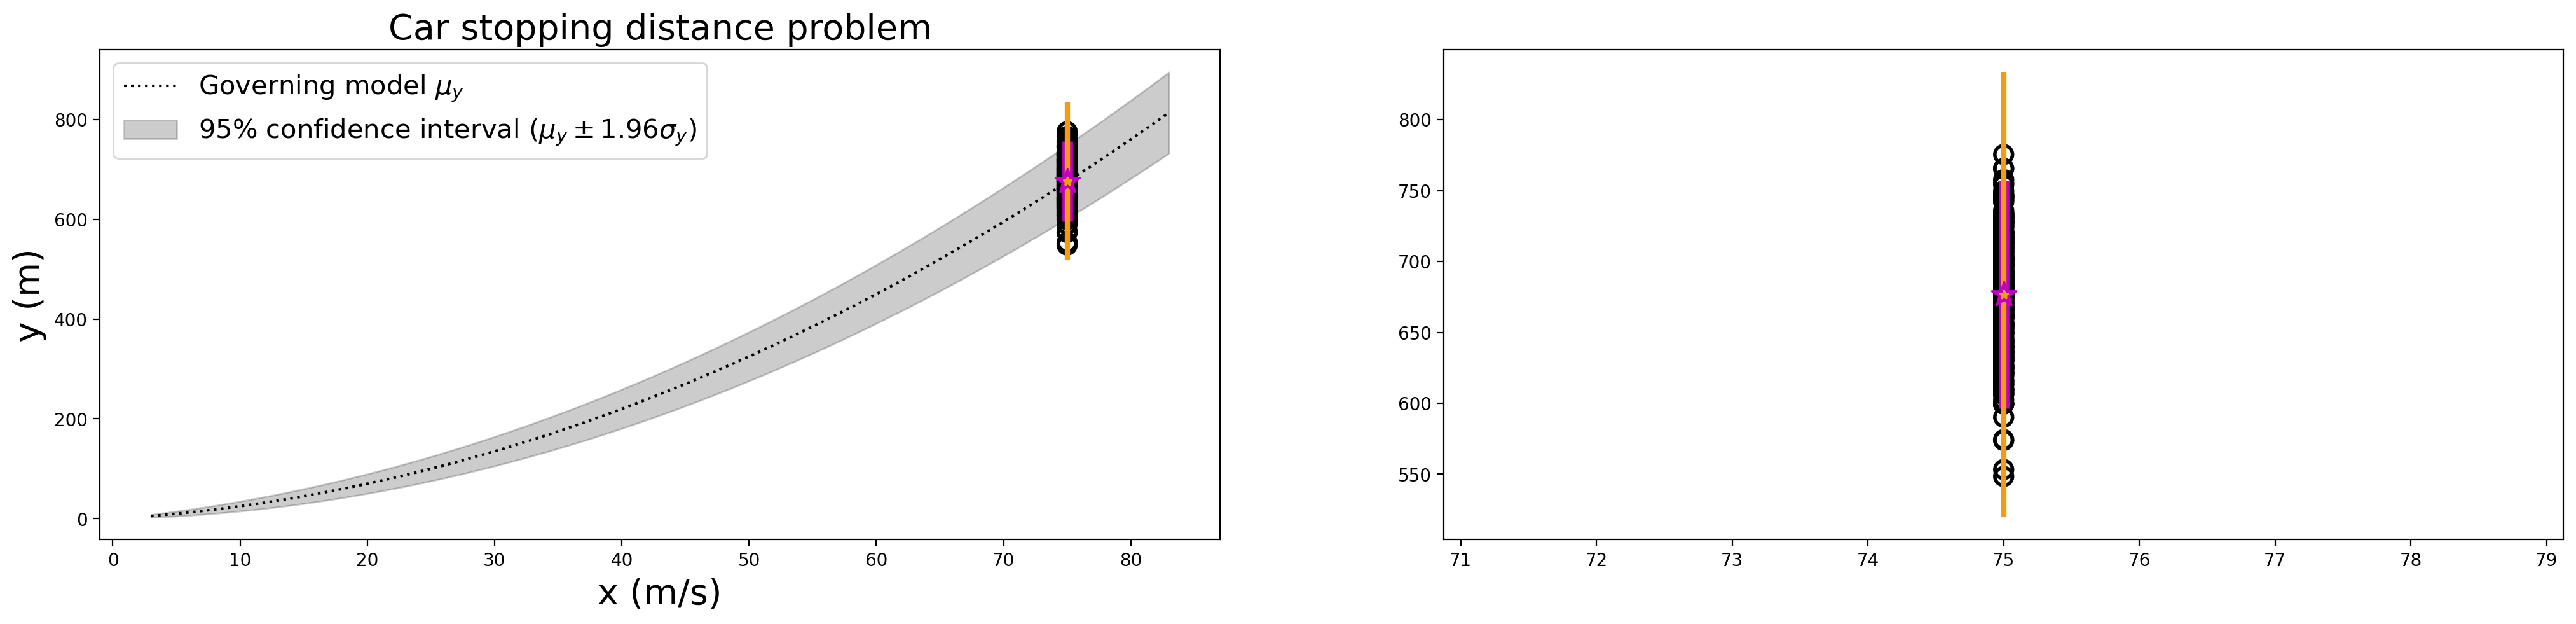

In [7]:
fig_car_PPD, ax_car_PPD = plt.subplots(1,2); plt.close() # create figure and close it
if fig_car_new.get_axes():
    del ax_car_PPD; del fig_car_PPD; fig_car_PPD, ax_car_PPD = plt.subplots(1,2) # delete fig & axes & create them
N_samples = 300 # CHANGE THIS NUMBER AND RE-RUN THE CELL
x = 75; empirical_y = samples_y(N_samples, x); # Empirical measurements of N_samples at x=75
empirical_mu_y = np.mean(empirical_y); empirical_sigma_y = np.std(empirical_y); # empirical mean and std
# Calculate PPD mean and standard deviation:
PPD_mu_y = np.mean(empirical_y); sigma_yGIVENz = 80; PPD_sigma_y = np.sqrt( sigma_yGIVENz**2*(1/N_samples + 1) )
car_fig(ax_car_PPD[0]) # a function I created to include the background plot of the governing model
for i in range(2): # create two plots (one is zooming in on the error bar)
    ax_car_PPD[i].errorbar(x , empirical_mu_y,yerr=1.96*empirical_sigma_y, fmt='m*', markersize=15, elinewidth=6);
    ax_car_PPD[i].errorbar(x , PPD_mu_y,yerr=1.96*PPD_sigma_y, color='#F39C12', fmt='*', markersize=5, elinewidth=3);
    ax_car_PPD[i].scatter(x*np.ones_like(empirical_y),empirical_y, s=100,facecolors='none', edgecolors='k', linewidths=2.0)
print("PPD & empirical mean[y] tend to the same value:",empirical_mu_y, "(real mean[y]=675)")
print("PPD std[y] we predict is",PPD_sigma_y, "& empirical std[y] is",empirical_sigma_y,"(real std[y]=37.5)")
fig_car_PPD.set_size_inches(25, 5) # scale figure to be wider (since there are 2 subplots)

### Reflection on what we are observing

1. Generally speaking, our PPD is quite reasonable and the result should be intuitive!
    * For few data points, the variance of the PPD is a bit larger than the variance we assumed for the conditional pdf $p(y|z)$, i.e. $\sigma_{y|z}^2=s^2=80^2$.

2. As the number of data points increases (see PPD as $N\rightarrow \infty$ or play with the figure above by increasing $N$), then the variance of the PPD $\sigma_{y}^2 \rightarrow s^2=80^2$ tends to the variance we assumed for our model: $\sigma_{y|z}^2=s^2=80^2$.
    * This results from our choice of likelihood and prior... Our model was incorrect in both:
        * The hidden rv $z$ is actually a Gaussian distribution, instead of a noninformative Uniform distribution
        * The real conditional pdf is the Dirac "distribution" around value $y = zx + 0.1 x^2$, instead of the Gaussian distribution with a mean of $\mu_{y|z}= zx + 0.1 x^2$ and a variance of $\sigma_{y|z} = s^2 = 80^2$.

Please keep this in your head:
* (Bayesian) ML is not magic. Every modeling choice you make affects the predictions you get.
* Of course, there are ways of getting "closer" to the truth! We'll take steps in that direction in the remainder of the course. 

## Multivariate Gaussian Distribution

Now that we understand univariate Bayesian inference and the PPD, let's extend to multiple variables.

**Why this matters**: Gaussian Process regression (Lecture 3) relies on conditioning multivariate Gaussians—this is the mathematical foundation.

**Topics:**
- Generalizing from univariate to multivariate Gaussian
- The covariance matrix
- Conditioning multivariate Gaussians

## Multivariate Gaussian <a title="probability density function">pdf</a> (a.k.a. <a title="Multivariate normal">MVN</a> distribution)

The multivariate Gaussian <a title="probability density function">pdf</a> of a $D$-dimensional vector $\mathbf{x}$ is given by,

$$
\begin{align}
p(\mathbf{x}|\boldsymbol{\mu},\boldsymbol{\Sigma}) & = \frac{e^{-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})}}{\sqrt{(2\pi)^D |\boldsymbol{\Sigma}|}} \\
& = \frac{1}{(2\pi)^{D/2} |\boldsymbol{\Sigma}|^{1/2}} \exp\left[ -\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right]
\end{align}
$$

where $\boldsymbol{\mu}=\mathbb{E}[\mathbf{x}]\in \mathbb{R}^D$ is the mean vector, and $\boldsymbol{\Sigma}= \text{Cov}[\mathbf{x}]$ is the $D\times D$ **covariance matrix**. 

### Covariance matrix

The covariance matrix is a natural generalization of the variance (Lecture 1) for the multivariate case!

$$
\begin{align}
\boldsymbol{\Sigma} = \text{Cov}[\mathbf{x}] &= \mathbb{E}\left[(\mathbf{x}-\mathbb{E}[\mathbf{x}])(\mathbf{x}-\mathbb{E}[\mathbf{x}])^T \right] \\
 &= \begin{bmatrix}
\mathbb{V}[x_1] & \text{Cov}[x_1,x_2] & \cdots & \text{Cov}[x_1, x_D] \\
\text{Cov}[x_2,x_1] & \mathbb{V}[x_2] & \cdots & \text{Cov}[x_2, x_D] \\
\vdots          & \vdots & \ddots & \vdots \\
\text{Cov}[x_D,x_1] & \text{Cov}[x_D,x_2] & \cdots & \mathbb{V}[x_D] \\
\end{bmatrix}
\end{align}
$$

where $\text{Cov}[x_i,x_j] = \mathbb{E}\left[(x_i-\mathbb{E}[x_i])(x_j-\mathbb{E}[x_j])\right] = \mathbb{E}[x_i x_j] - \mathbb{E}[x_i]\mathbb{E}[x_j]$

Also note that $\mathbb{V}[x_i]=\text{Cov}[x_i,x_i]$.

#### Notes about covariance and normalized covariance (correlation coefficient)

The covariance between two rv's $y$ and $z$ measures the degree to which $y$ and $z$ are **linearly** related.

Covariances can be between negative and positive infinity.

Sometimes it is more convenient to work with a normalized measure, with a finite lower and upper bound. The (Pearson) **correlation coefficient** between $y$ and $z$ is defined as

$$
\rho = \text{corr}[y,z] = \frac{\text{Cov}[y,z]}{\sqrt{\mathbb{V}[y]\mathbb{V}[z]}}
$$

Covariance and correlation coefficient measure the same relationship.

#### Note about normalized covariance (correlation coefficient)

Several sets of $(y_i, z_i)$ points, with the correlation coefficient of $y$ and $z$ for each set.

<img src="../figures/Correlation_examples2.svg" title="Correlation coefficient" width="65%" align="right">
Top row: $\text{corr}[y,z]$ reflects the noisiness and direction of a linear relationship.

Middle row: $\text{corr}[y,z]$ **does not** reflect the slope of that relationship

Bottom row: $\text{corr}[y,z]$ **does not** reflect many aspects of nonlinear relationships.

(Additional note: the figure in the center has a slope of 0 but in that case the correlation coefficient is undefined because the variance of $z$ is zero.)

## Understanding the MVN pdf (a common joint pdf)

$$
\begin{align}
p(\mathbf{x}|\boldsymbol{\mu},\boldsymbol{\Sigma}) & = \frac{e^{-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\mu)}}{\sqrt{(2\pi)^D |\boldsymbol{\Sigma}|}} \\
& = \frac{1}{(2\pi)^{D/2} |\boldsymbol{\Sigma}|^{1/2}} \exp\left[ -\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^T\boldsymbol{\Sigma}^{-1}(\mathbf{x}-\boldsymbol{\mu})\right]
\end{align}
$$

where $\boldsymbol{\mu}=\mathbb{E}[\mathbf{x}]\in \mathbb{R}^D$ is the mean vector, and $\boldsymbol{\Sigma}= \text{Cov}[\mathbf{x}]$ is the $D\times D$ **covariance matrix**. 

* Multivariate Gaussian pdf's are very important in ML and Statistics.

* Let's discover their properties by working out some examples.

### Example: MVN from independent Gaussian rv's

Consider two **independent** rv's $x_1$ and $x_2$ where each of them is a univariate Gaussian pdf:

$$
x_1 = \mathcal{N}(x_1|\mu_{x_1}, \sigma_{x_1}^2)
$$

$$
x_2 = \mathcal{N}(x_2|\mu_{x_2}, \sigma_{x_2}^2)
$$

where $\mu_{x_1}=10$, $\sigma_{x_1}^2=5^2$, $\mu_{x_2}=0.5$ and $\sigma_{x_2}^2=2^2$.

Let's plot the joint pdf $p(x_1, x_2)=p(x_1) p(x_2)$.

In [8]:
# This code is hidden during presentation (shown as notes).
from scipy.stats import norm # import from scipy.stats the normal distribution
from matplotlib.gridspec import GridSpec # for more control over subplots that have 2D and 3D axes
#from matplotlib import cm 

mu_x1 = 10.0; sigma_x1 = 5; # parameters of p(x1)
mu_x2 = 0.5; sigma_x2 = 2.0 # parameters of p(x2)

# Since x1 and x2 are independent, we don't even need to call multivariate_normal from scipy.stats
N_samples = 300 # number of samples
x1range = np.linspace(-3*sigma_x1+mu_x1, 3*sigma_x1+mu_x1, N_samples) # x1 values for plotting
x2range = np.linspace(-3*sigma_x2+mu_x2, 3*sigma_x2+mu_x2, N_samples) # x2 values for plotting
samples_x1 = norm.rvs(mu_x1, sigma_x1, size=N_samples) # sample from p(x1)
samples_x2 = norm.rvs(mu_x2, sigma_x2, size=N_samples) # sample from p(x2)

# This figure is created such that the histograms seem a projection of the 3D plot
# I used a simple trick of creating a grid of 4x3 subplots and assigning a 3x3 grid to the 3D plot alone
fig_joint_pdf = plt.figure()
gs = GridSpec(4, 3) # to handle subplot placement easier

# Subplot with a 3D surface of the joint pdf p(y,z):
ax_joint_pdf = fig_joint_pdf.add_subplot(gs[1:,0:], projection='3d')
ax_joint_pdf.set_facecolor('white') # set background for this subplot
x1_grid,x2_grid = np.meshgrid(x1range,x2range) # grid for surface plot
joint_pdf_grid = norm.pdf(x1_grid,mu_x1,sigma_x1)*norm.pdf(x2_grid,mu_x2,sigma_x2) # joint pdf values
ax_joint_pdf.plot_wireframe(x1_grid, x2_grid, joint_pdf_grid, color = 'grey', alpha=0.5) # surface plot
ax_joint_pdf.scatter(samples_x1,samples_x2,np.zeros(N_samples), alpha = .7, s = 10) # samples in the z-y plane
ax_joint_pdf.scatter(np.mean(samples_x1), np.mean(samples_x2), marker = "d", c = "r", s=100) # show the mean
ax_joint_pdf.set_xlabel(r"$x_1$", fontsize=20)
ax_joint_pdf.xaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf.set_ylabel(r"$x_2$", fontsize=20)
ax_joint_pdf.yaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf.set_zlabel(r"$p(x_1,x_2)$", fontsize=20)
ax_joint_pdf.zaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf.set_xlim3d(-3*sigma_x1+mu_x1,3*sigma_x1+mu_x1) # x1 axis limits
ax_joint_pdf.set_ylim3d(-3*sigma_x2+mu_x2,3*sigma_x2+mu_x2) # x2 axis limits

# Remind the histogram and pdf for z
ax_hist_x1 = fig_joint_pdf.add_subplot(gs[0,2])
ax_hist_x1.hist(samples_x1, bins='auto', density=True, label='Histogram')  
ax_hist_x1.plot(x1range, norm.pdf(x1range, mu_x1, sigma_x1), 'k--', linewidth = 3, label='$p(x_1)$')
ax_hist_x1.set_xlabel("$x_1$", fontsize=20)
ax_hist_x1.set_ylabel("probability density", fontsize=20)
ax_hist_x1.legend(fontsize=15, loc='upper left');

# Create the histogram and pdf for y|z again (to remind about the scaling)
ax_hist_x2 = fig_joint_pdf.add_subplot(gs[0,0]) # place it in position [1,0] in the 3x3 grid
ax_hist_x2.hist(samples_x2, bins='auto', density=True, label='Histogram')  
ax_hist_x2.plot(x2range, norm.pdf(x2range, mu_x2, sigma_x2),
               'k--', linewidth = 3, label='$p(x_2)$')
ax_hist_x2.set_xlabel("$x_2$", fontsize=20)
ax_hist_x2.set_ylabel("probability density", fontsize=20)
ax_hist_x2.legend(fontsize=15, loc='upper left');

# Create figure with specified size but close it so that we open the figure just for presentation
fig_joint_pdf.set_size_inches(20, 10) # scale figure to be wider (since there are 2 subplots)
plt.close(fig_joint_pdf) # do not plot the figure now. We will show it in a later cell

# Second visualization: surface + contour plot
#Make a 3D plot
fig_joint_pdf_color = plt.figure()
gs = GridSpec(1, 3) # to handle subplot placement easier

# Subplot with a 3D surface of the joint pdf p(y,z):
ax_joint_pdf_color_surface = fig_joint_pdf_color.add_subplot(gs[0,:2], projection='3d') # use 1x2 grid
ax_joint_pdf_color_surface.set_facecolor('white') # set background for this subplot
ax_joint_pdf_color_surface.plot_surface(x1_grid, x2_grid, joint_pdf_grid,cmap='viridis',linewidth=0)
ax_joint_pdf_color_surface.set_xlabel('$x_1$', fontsize=20)
ax_joint_pdf_color_surface.xaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf_color_surface.set_ylabel('$x_2$', fontsize=20)
ax_joint_pdf_color_surface.yaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf_color_surface.set_zlabel('probability density of $p(x_1, x_2)$', fontsize=20)
ax_joint_pdf_color_surface.zaxis.labelpad=20 # offset label from numbers (to avoid overlap)

# Subplot with the contour of the joint pdf p(y,z)
ax_joint_pdf_color_contour2 = fig_joint_pdf_color.add_subplot(gs[0,2])
CS = ax_joint_pdf_color_contour2.contourf(x1_grid, x2_grid, joint_pdf_grid, 50, cmap="viridis")
ax_joint_pdf_color_contour2.set_xlabel('$x_1$', fontsize=20)
ax_joint_pdf_color_contour2.set_ylabel('$x_2$', fontsize=20)
cbar = fig_joint_pdf_color.colorbar(CS) # Make a colorbar for the ContourSet returned by the contourf call.
cbar.ax.set_ylabel('probability density of $p(x_1, x_2)$', fontsize=20)
#ax_MVN_contour2.set_title('Multivariate Normal distribution (MVN)', fontsize=20)

# Create figure with specified size
fig_joint_pdf_color.set_size_inches(25, 10)
plt.close(fig_joint_pdf_color) # do not plot the figure now. We will show it in a later cell

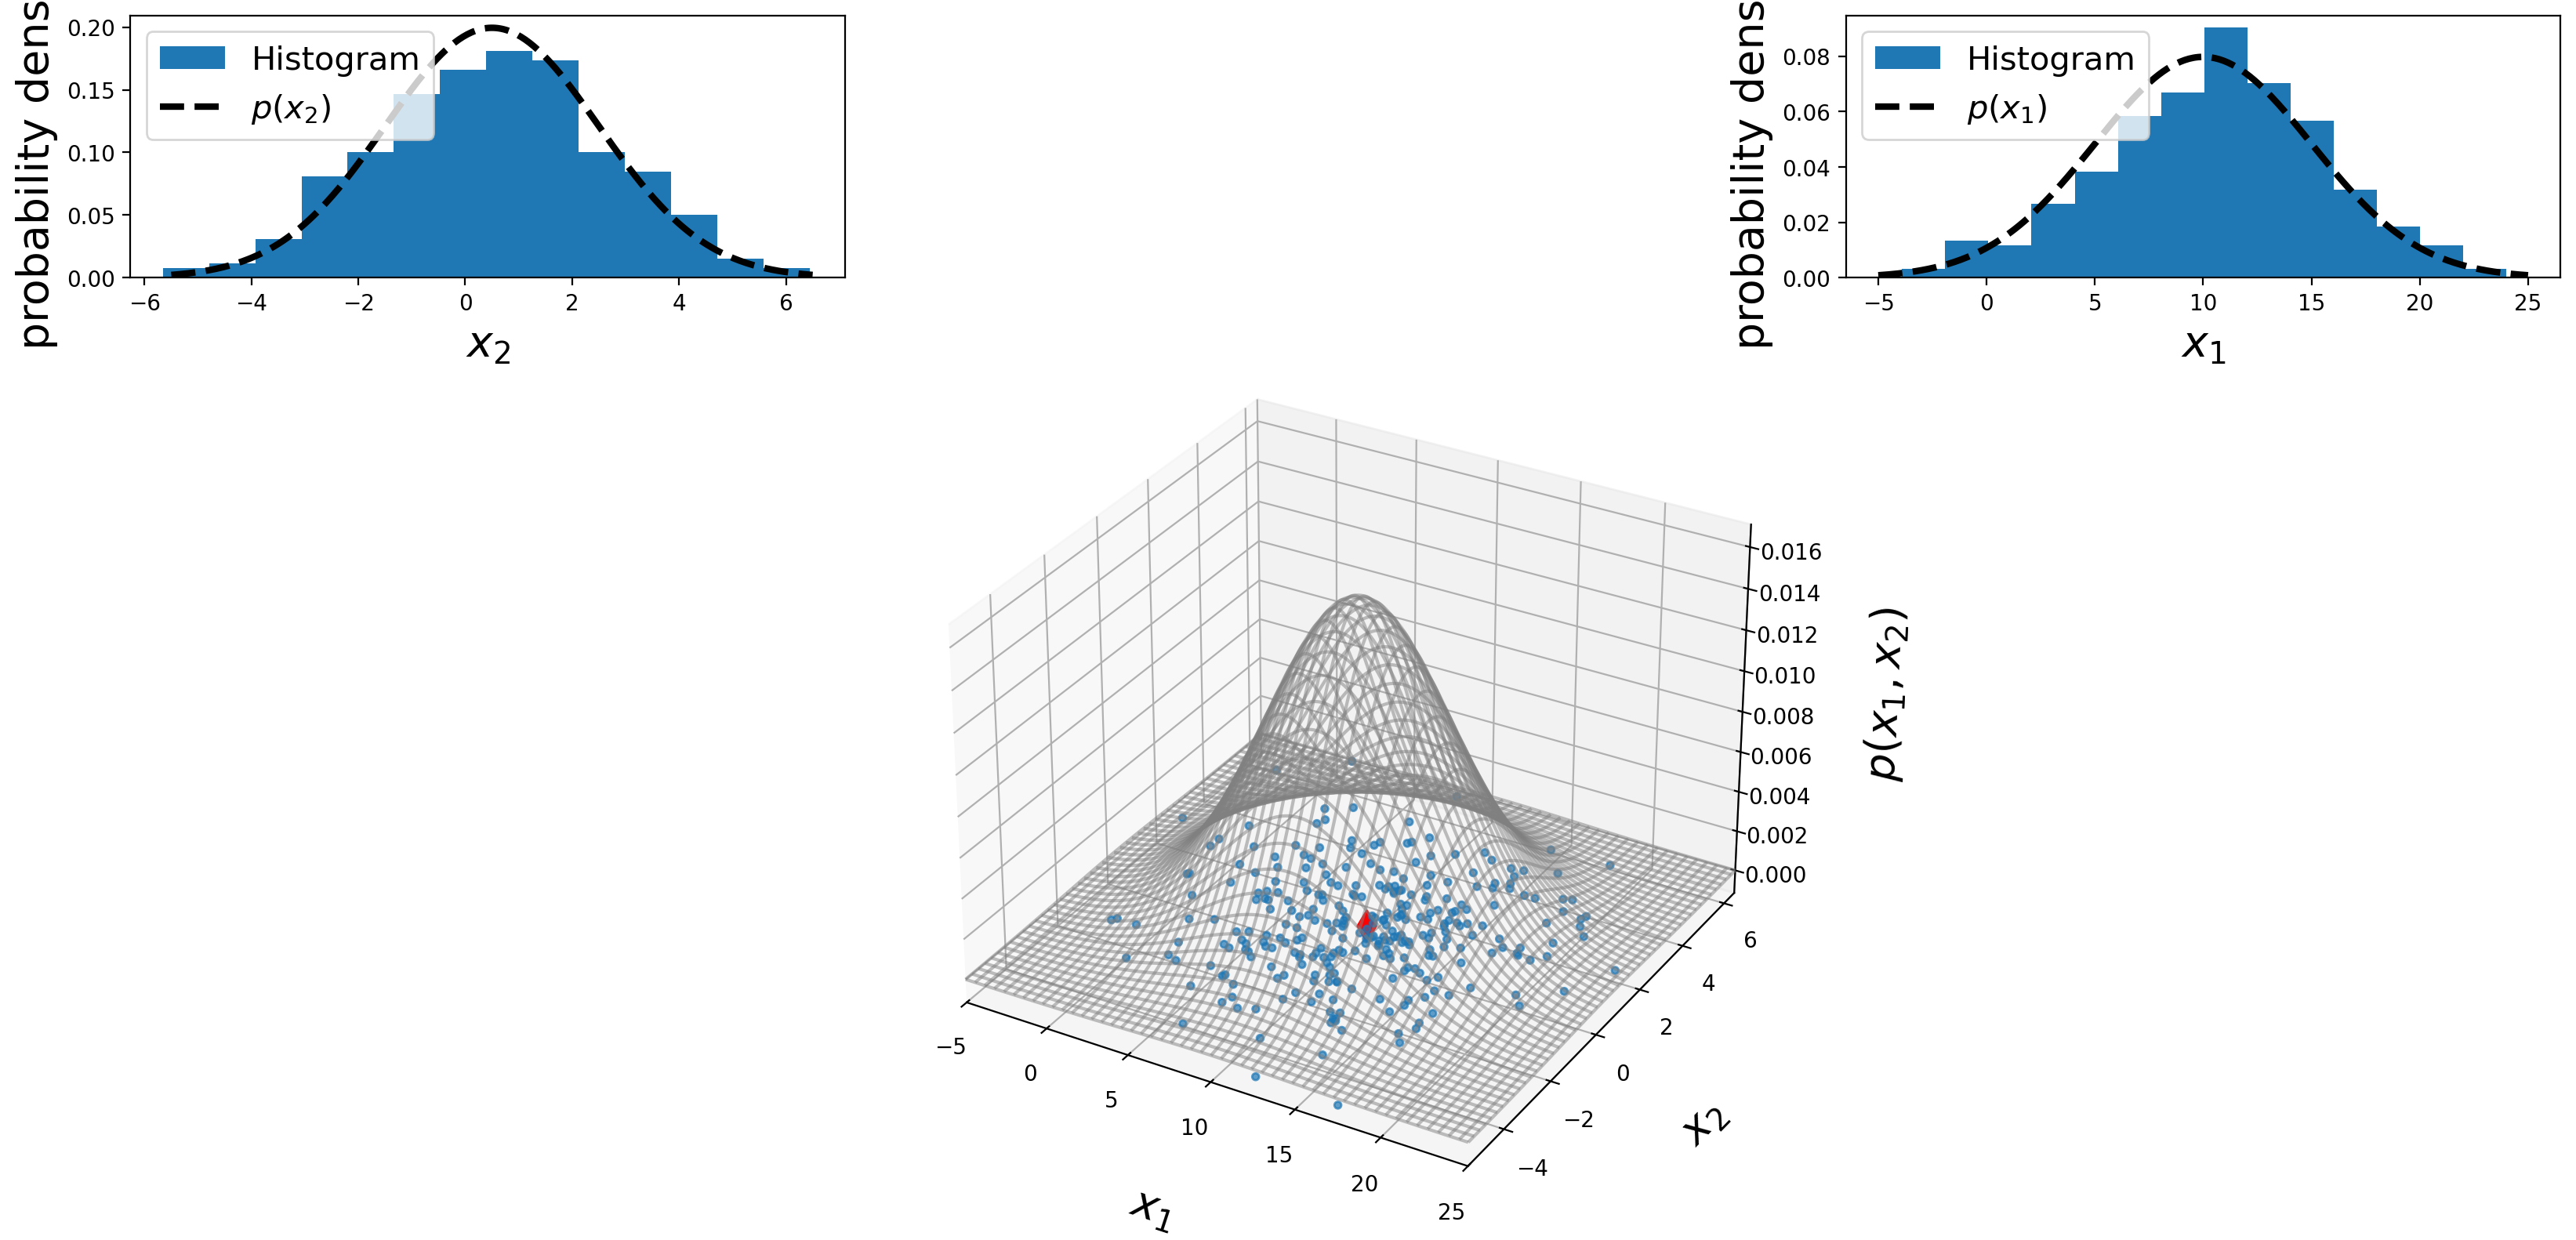

In [9]:
# HIGHLIGHT DIFFERENCE IN MAXIMUM PROBABILITY DENSITIES!!
fig_joint_pdf # The joint pdf results from the multiplication...

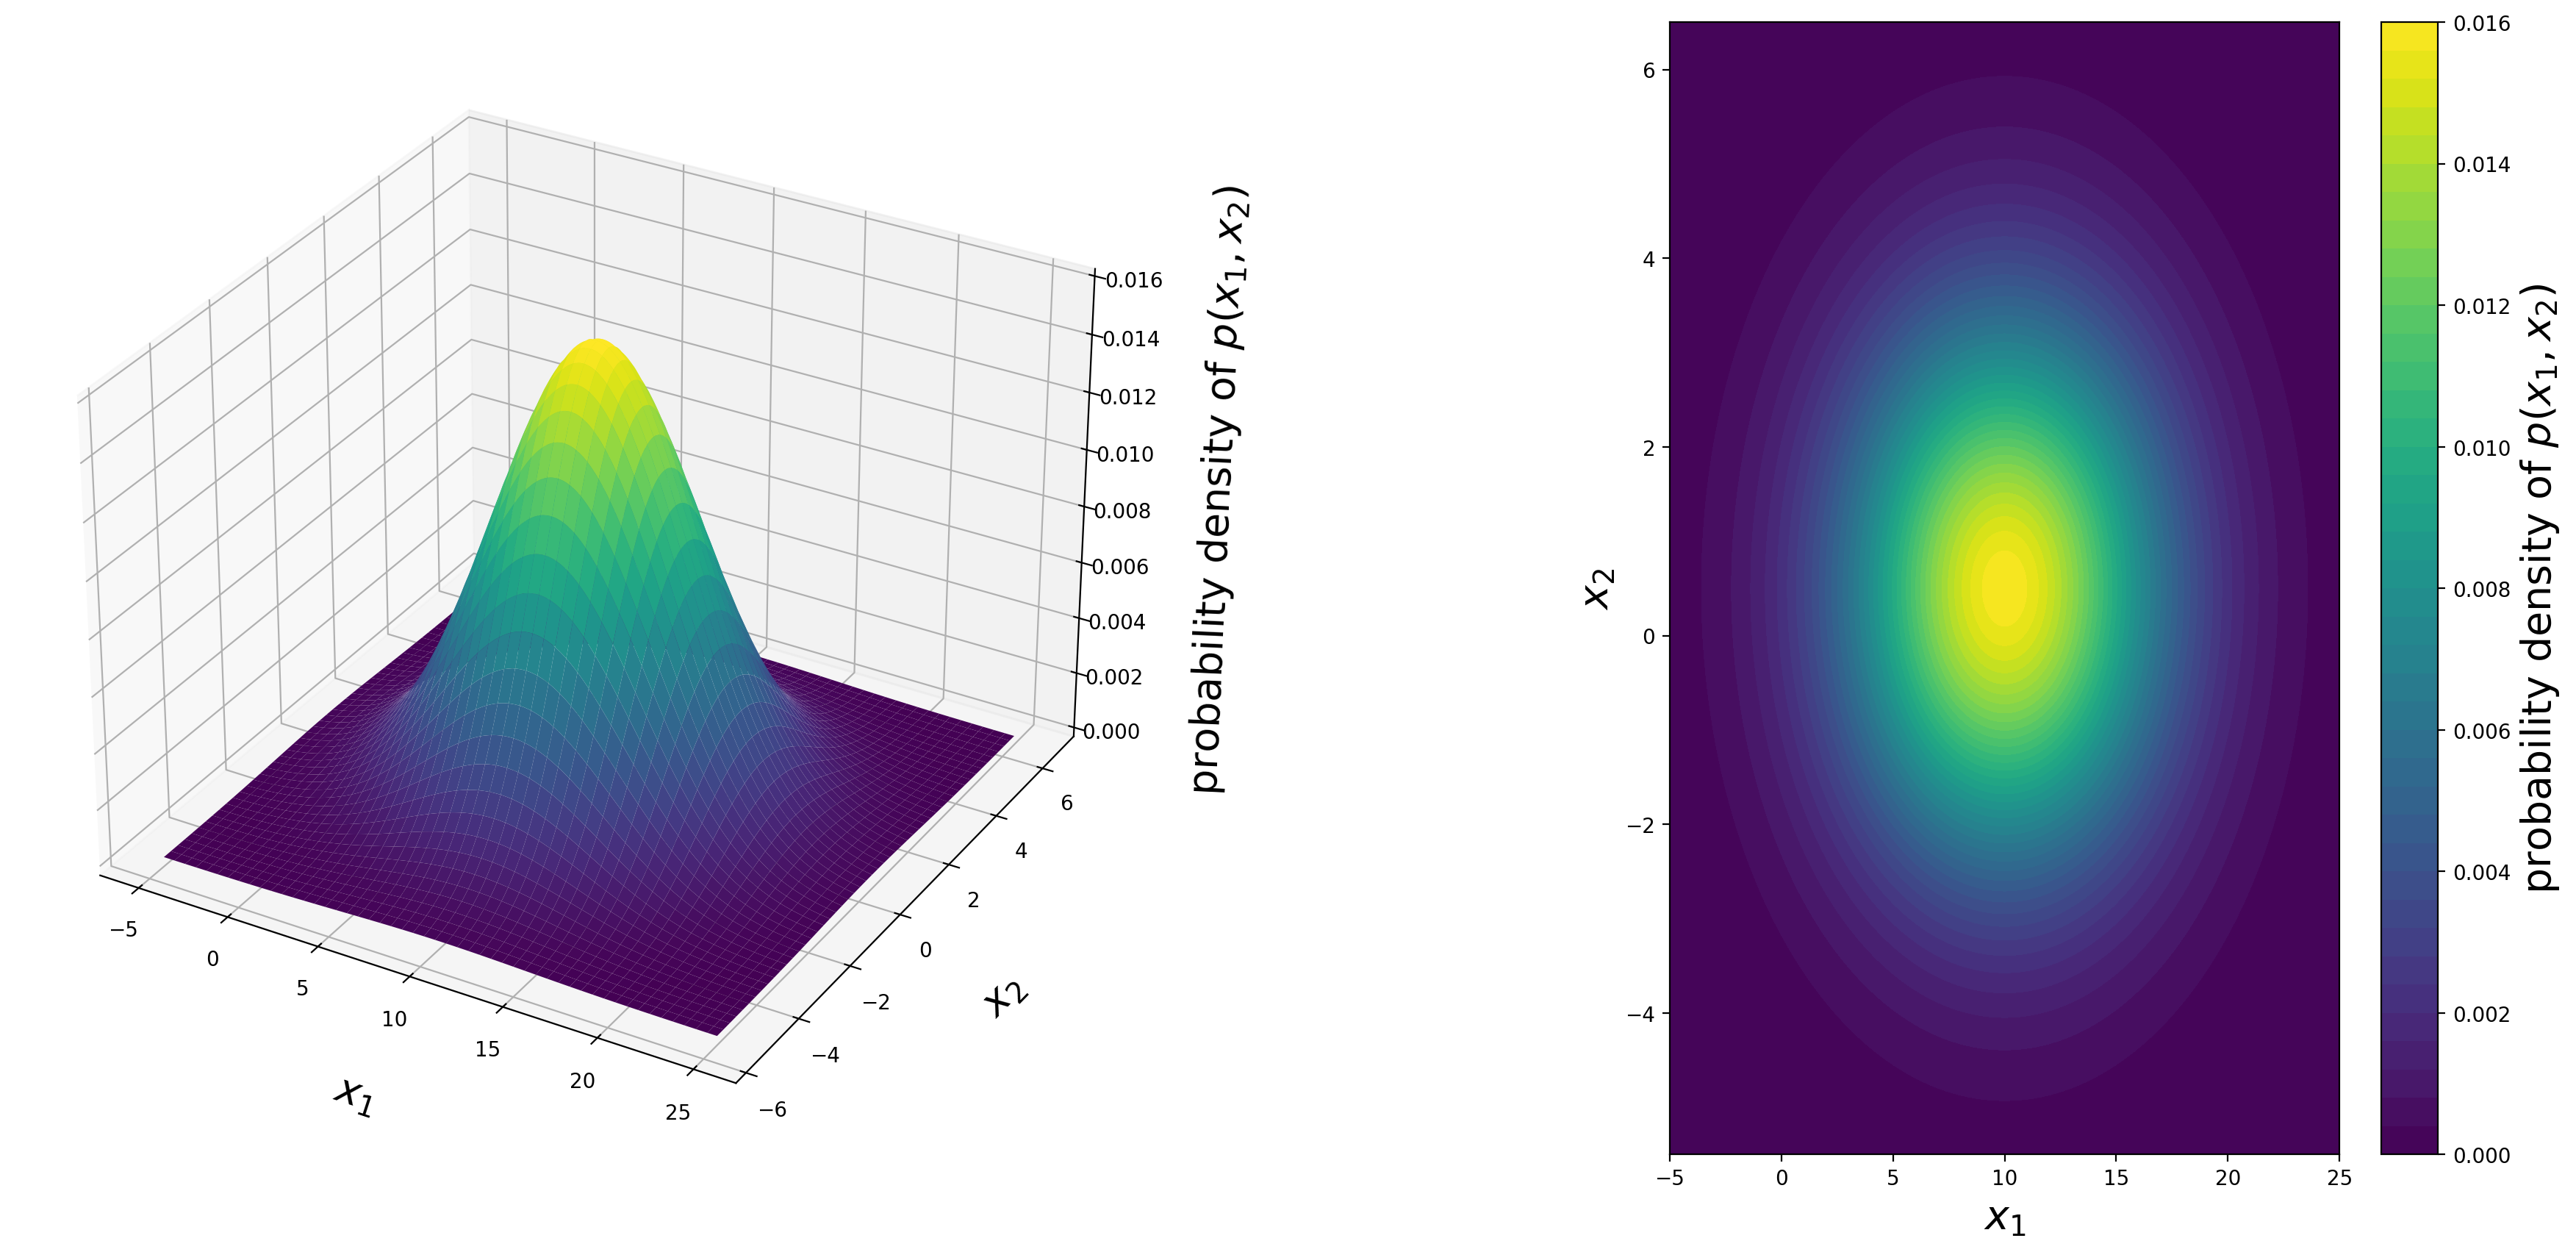

In [10]:
# Same pdf but now as a surface plot and as a contour plot.
fig_joint_pdf_color

### What if the conditional pdf was different?

Let's consider a slightly different case where, instead of knowing that $p(y|z) = \delta\left(y-(75 z+562.5)\right)$, we consider the conditional pdf as:

$$p(y|z) = \mathcal{N}\left(y|\mu_{y|z}=75 z+562.5,\sigma_{y|z}^2=30^2\right)$$

and that we still consider $p(z) = \mathcal{N}\left(z|\mu_z=1.5,\sigma_z^2=0.5^2\right)$.

Given the above considerations, the joint pdf is now:

$$p(y,z) = \mathcal{N}\left(y|\mu_{y|z}=75 z+562.5,\sigma_{y|z}^2=30^2\right) \mathcal{N}\left(z|\mu_z=1.5,\sigma_z^2=0.5^2\right)$$

In [11]:
# Let's plot the conditional, prior and joint pdfs:
x = 75; # constant velocity

# Parameters for p(z):
mu_z = 1.5; sigma_z = 0.5;

# Parameters for p(y|z):
def calculate_mu_yGIVENz(z_value,x): # note that the mean of p(y|z) depends on z
    mu_yGIVENz = x*z_value+0.1*x**2
    return mu_yGIVENz

# Below I will also include a "function" to compute the std of p(y|z) dependent on z
# but this is not needed because in this example the std is always the same for any z.
def calculate_sigma_yGIVENz(): # note that the std of p(y|z) does NOT depend on z
    sigma_yGIVENz = 30 # Assumed value for the standard deviation of y|z (this one actually does not depend on z)
    return sigma_yGIVENz

#------------------------------------------------------------------------------------------
# It's instructive to calculate p(z), p(y|z) and p(y,z) by defining functions (although it is slower...)

# Calculate a sample from p(z), i.e. z ~ N(mu_z, sigma_z):
def pdf_z(z_value,mu_z, sigma_z):
    pdf_z = norm.pdf(z_value, mu_z, sigma_z) # p(z_value)
    return pdf_z

# Parameters for p(y|z):
def pdf_yGIVENz(y_value,z_value, x):
    # NOTE two things about p(y|z):
    #      1. this pdf is both a function of y and of the given values of z
    #      2. this pdf has a constant variance, but that is not the case for its mean!
    mu_yGIVENz = calculate_mu_yGIVENz(z_value,x) # note that mean of p(y|z) depends on the value of z
    sigma_yGIVENz = calculate_sigma_yGIVENz() # in this case it's always a constant
    pdf_yGIVENz = norm.pdf(y_value, mu_yGIVENz, sigma_yGIVENz) # p(y_value|z_value)
    return pdf_yGIVENz

# Parameters for joint pdf p(y,z):
def pdf_joint_y_z(y_value,z_value, x,mu_z,sigma_z):
    # compute p(y_value,z_value) by calling the respective functions:
    pdf_joint_y_z = pdf_yGIVENz(y_value,z_value, x)*pdf_z(z_value,mu_z, sigma_z)
    # just one sample from p(y,z)
    return pdf_joint_y_z

# Take a sample from z ~ p(z) and y ~ p(y|z):
def samples_from_y_and_z(mu_z,sigma_z,x):
    sample_z = norm.rvs(mu_z, sigma_z) # just one sample from p(z)
    mu_yGIVENz = calculate_mu_yGIVENz(sample_z,x) # note that mean of p(y|z) depends on the value of z
    sigma_yGIVENz = calculate_sigma_yGIVENz() # in this case it's always a constant
    sample_yGIVENz = norm.rvs(mu_yGIVENz, sigma_yGIVENz) # just one sample from p(y|z)
    return sample_yGIVENz, sample_z
#------------------------------------------------------------------------------------------

N_samples = 300 # number of samples to create histograms and plots
# Create grid of points for plotting the p(y,z):
z_grid_min = -3*sigma_z+mu_z # minimum value of z in plot
z_grid_max = 3*sigma_z+mu_z # maximum value of z in plot

# Determining the range of y can be a little tricky because we don't know p(y).
# We don't know yet how to calculate the marginal pdf p(y), as we need to solve the integral
# of the joint pdf p(y,z) wrt to z and we have not learned how to do that yet
# (we will learn that in the next lecture). Anyway, the result is a Gaussian with mu_y and
# sigma_y equal to:
mu_y = x*mu_z+0.1*x**2
sigma_y = np.sqrt( x**2*( (calculate_sigma_yGIVENz()/x)**2 + sigma_z**2 ) )

# So, now we can calculate the grid of points for plotting p(y,z)
y_grid_min = -3*sigma_y+mu_y # minimum value of y in plot
y_grid_max =  3*sigma_y+mu_y # maximum value of y in plot

# Define range of y_grid
y_grid, z_grid = np.mgrid[y_grid_min:y_grid_max:6*sigma_y/N_samples,
                           z_grid_min:z_grid_max:6*sigma_z/N_samples]
#
pos = np.dstack((y_grid, z_grid)) # put all the grid points into a single matrix for convenience
joint_pdf_y_z_grid = np.zeros_like(y_grid)
for idx_i, pos_i in enumerate(pos):
    for idx_j, pos_j in enumerate(pos_i):
        z_value = pos_j[1] # z1 value for this grid point
        y_value = pos_j[0] # z1 value for this grid point
        joint_pdf_y_z_grid[idx_i,idx_j] = pdf_joint_y_z(y_value,z_value, x,mu_z,sigma_z)

samples_yGIVENz = np.zeros(N_samples); samples_z = np.zeros(N_samples);
# Create N_samples of z and y:
for i_sample in range(N_samples):
    samples_yGIVENz[i_sample], samples_z[i_sample] = samples_from_y_and_z(mu_z,sigma_z,x)

# This figure is created such that the histograms seem a projection of the 3D plot
# I used a simple trick of creating a grid of 4x3 subplots and assigning a 3x3 grid to the 3D plot alone
fig_joint_pdf_new = plt.figure()
gs = GridSpec(4, 3) # to handle subplot placement easier

# Subplot with a 3D surface of the joint pdf p(y,z):
ax_joint_pdf_new = fig_joint_pdf_new.add_subplot(gs[1:,0:], projection='3d')
ax_joint_pdf_new.set_facecolor('white') # set background for this subplot
ax_joint_pdf_new.plot_wireframe(z_grid, y_grid, joint_pdf_y_z_grid, color = 'grey', alpha=0.5)
# samples in the z1-y plane:
ax_joint_pdf_new.scatter(samples_z,samples_yGIVENz,np.zeros(N_samples), alpha = .7, s = 10)
# show the mean in z1-y plane:
ax_joint_pdf_new.scatter(np.mean(samples_z), np.mean(samples_yGIVENz), marker = "d", c = "r", s=100)
ax_joint_pdf_new.set_xlabel(r"$z$", fontsize=20)
ax_joint_pdf_new.xaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf_new.set_ylabel(r"$y$", fontsize=20)
ax_joint_pdf_new.yaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf_new.set_zlabel(r"$p(y,z)$", fontsize=20)
ax_joint_pdf_new.zaxis.labelpad=20 # offset label from numbers (to avoid overlap)
ax_joint_pdf_new.set_xlim3d(z_grid_min,z_grid_max) # z1 axis limits
ax_joint_pdf_new.set_ylim3d(y_grid_min,y_grid_max) # y axis limits
#ax_joint_pdf.set_title("Joint probability: $p(y,z1)$ [for fixed x=75]", fontsize=20)

# Remind the histogram and pdf for the marginal pdf p(z):
zrange = np.linspace(z_grid_min,z_grid_max,N_samples) # z range for plotting p(z1)
ax_hist_z_new = fig_joint_pdf_new.add_subplot(gs[0,2])
ax_hist_z_new.hist(samples_z, bins='auto', density=True, label='Histogram')  
ax_hist_z_new.plot(zrange, norm.pdf(zrange, mu_z, sigma_z), 'k--', linewidth = 3, label='$p(z)$')
ax_hist_z_new.set_xlabel("$z$", fontsize=20)
ax_hist_z_new.set_ylabel("probability density", fontsize=20)
ax_hist_z_new.legend(fontsize=15, loc='upper left');

# Finally, let's plot the pdf of p(y) that is obtained by integrating the joint pdf p(y,z) wrt to z:
yrange = np.linspace(-3*sigma_y+mu_y,3*sigma_y+mu_y,N_samples) # y range for plotting p(y)
samples_y = norm.rvs(mu_y, sigma_y, size=N_samples) # samples from p(y) for histogram
ax_hist_y_new = fig_joint_pdf_new.add_subplot(gs[0,0]) # place it in position [1,0] in the 3x3 grid
ax_hist_y_new.hist(samples_y, bins='auto', density=True, label='Histogram')  
ax_hist_y_new.plot(yrange, norm.pdf(yrange, mu_y, sigma_y),
                 'k--', linewidth = 3, label='$p(y)$')
ax_hist_y_new.set_xlabel("$y$", fontsize=20)
ax_hist_y_new.set_ylabel("probability density", fontsize=20)
ax_hist_y_new.legend(fontsize=15, loc='upper left');

# Create figure with specified size but close it so that we open the figure just for presentation
fig_joint_pdf_new.set_size_inches(20, 10) # scale figure to be wider (since there are 2 subplots)
plt.close(fig_joint_pdf_new) # do not plot the figure now. We will show it in a later cell

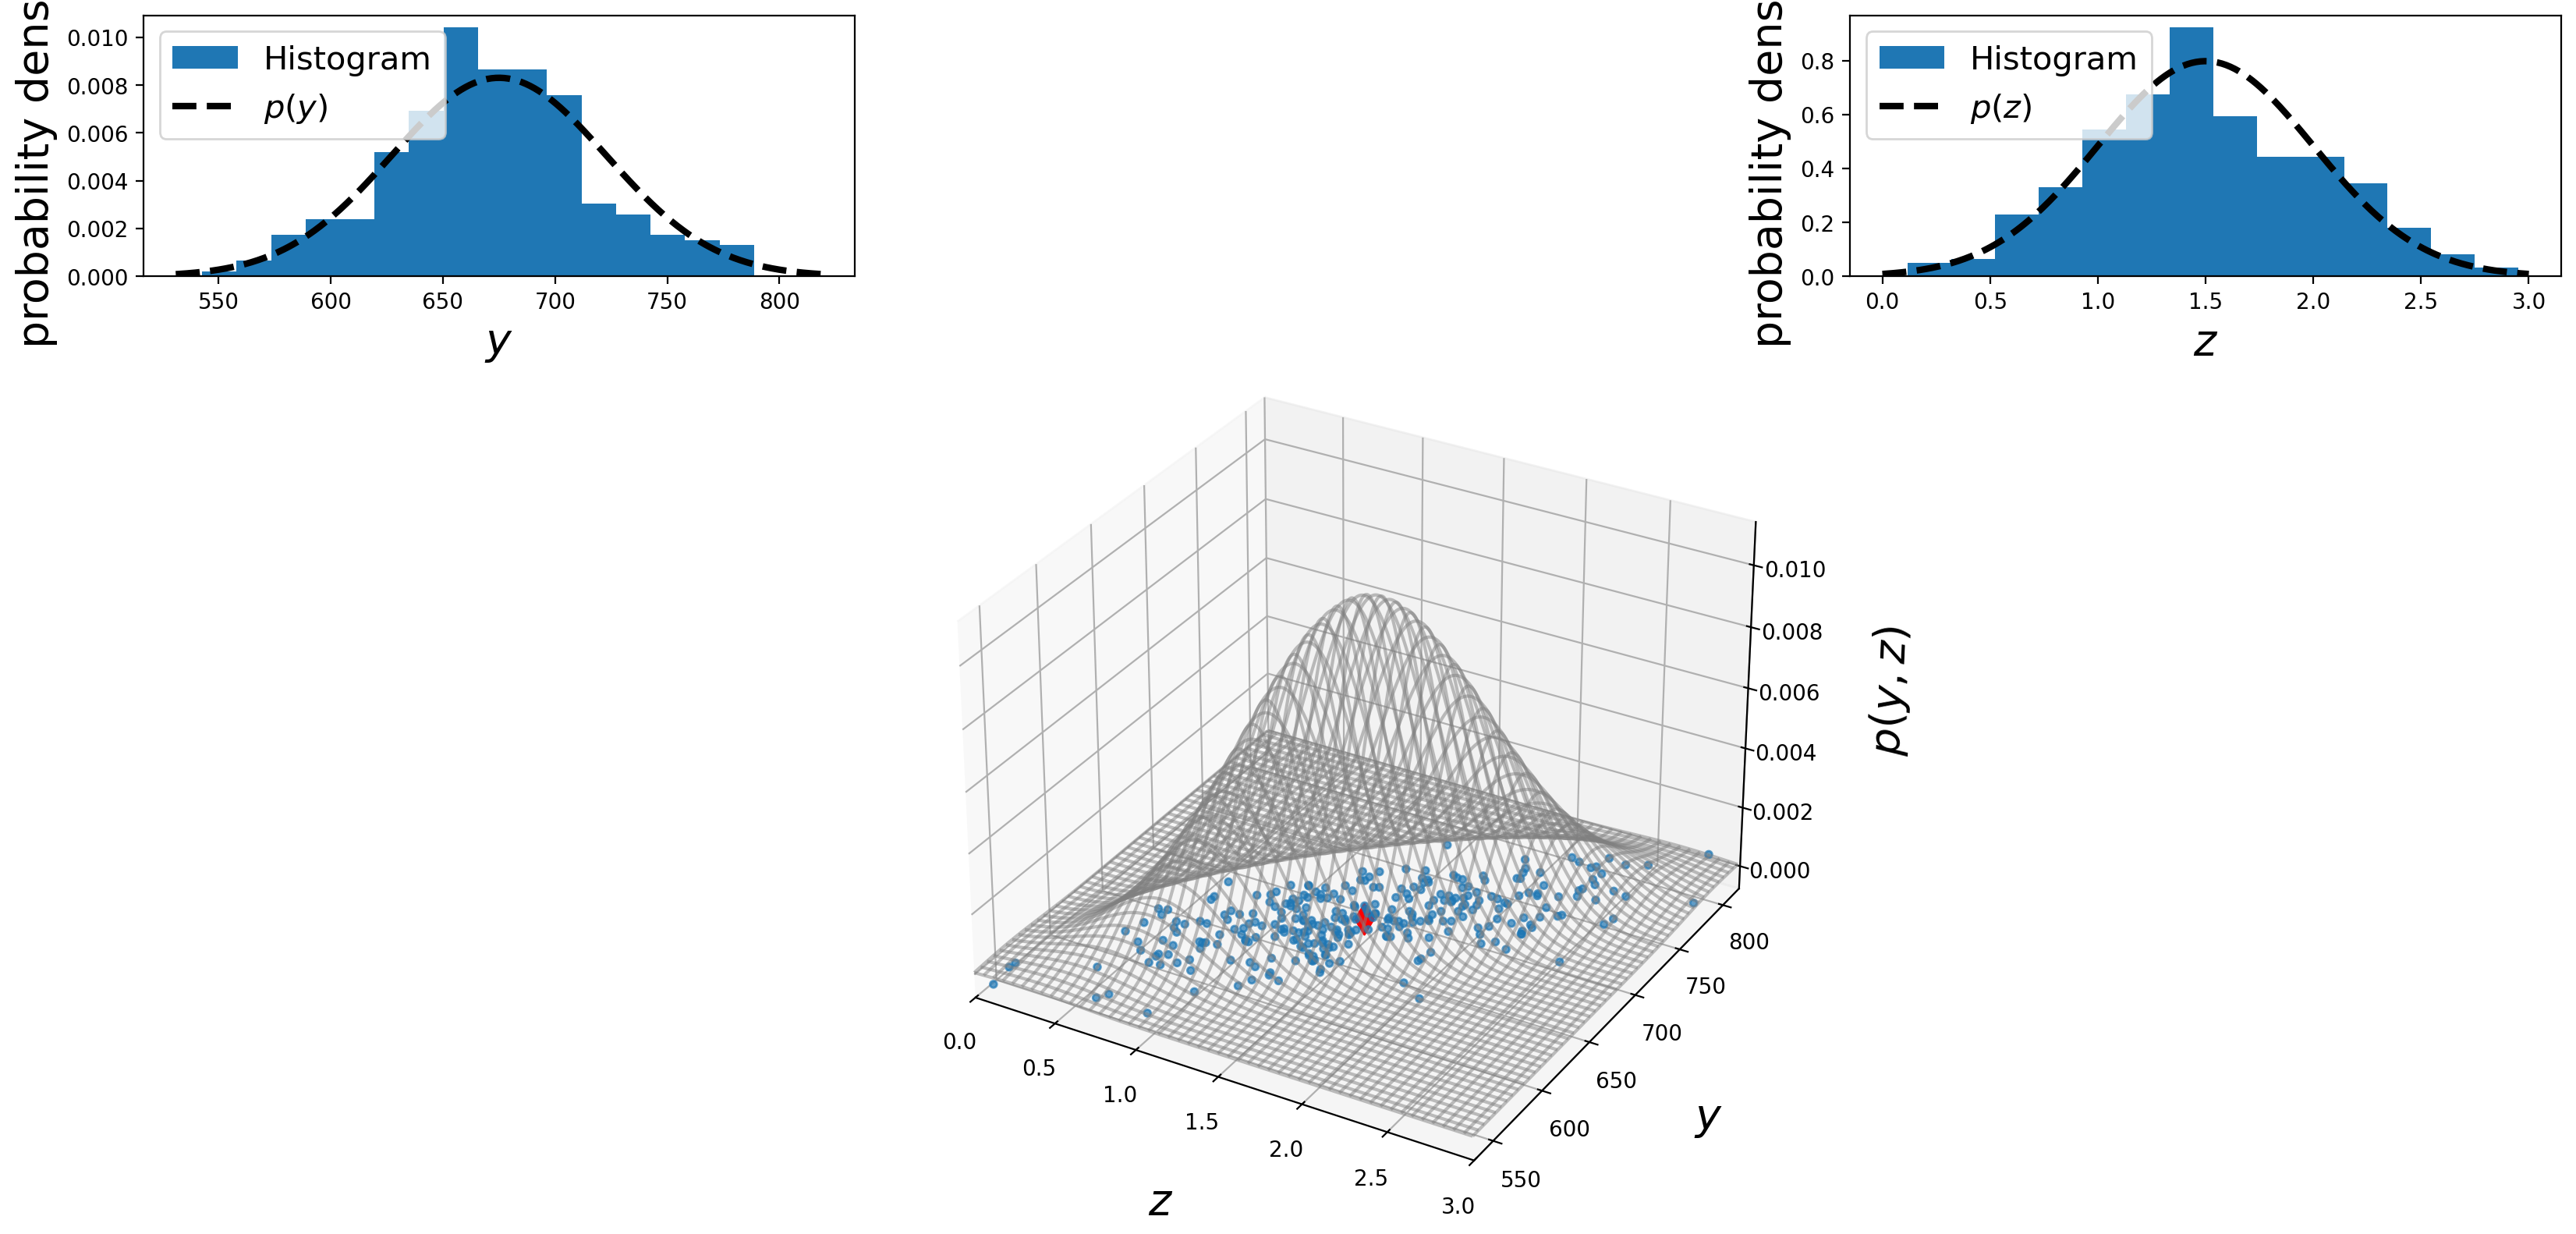

In [12]:
# HIGHLIGHT DIFFERENCE IN MAXIMUM PROBABILITY DENSITIES!!
fig_joint_pdf_new # The joint pdf results from the multiplication...

In [13]:
def fig2_joint_pdf_new(y_value,z_value): # Plot joint pdf again but now also show the two conditional pdfs
    # Replot the same joint pdf but using contour lines, so that students understand what a conditional pdf is.
    fig_joint_pdf_new_color = plt.figure()
    gs = GridSpec(1, 3) # to handle subplot placement easier
    n_points = 300  # Local constant to avoid global N_samples being overwritten

    # Subplot with a 3D surface of the joint pdf p(y,z):
    ax_joint_pdf_new_color_surface = fig_joint_pdf_new_color.add_subplot(gs[0,:2], projection='3d') # use 1x2 grid
    ax_joint_pdf_new_color_surface.set_facecolor('white') # set background for this subplot
    ax_joint_pdf_new_color_surface.contour3D(z_grid, y_grid, joint_pdf_y_z_grid, levels = 50,
                                            alpha = .2, cmap = "viridis")
    
    # Plot the pdf of p(y|z=z_value)
    yrange = np.linspace(y_grid_min,y_grid_max,n_points) # y range for plotting p(y|z1)
    pdf_yGIVENz = np.zeros_like(yrange)
    for i_point in range(n_points):
        pdf_yGIVENz[i_point] = pdf_joint_y_z(yrange[i_point],z_value, x,mu_z,sigma_z)
    ax_joint_pdf_new_color_surface.plot3D(z_value*np.ones_like(yrange), yrange, pdf_yGIVENz, 'r')
    
    # Plot the pdf of p(z|y=y_value)
    z1range = np.linspace(z_grid_min,z_grid_max,n_points) # y range for plotting p(y|z1)
    pdf_zGIVENy = np.zeros_like(z1range)
    for i_point in range(n_points):
        pdf_zGIVENy[i_point] = pdf_joint_y_z(y_value,z1range[i_point], x,mu_z,sigma_z)
    ax_joint_pdf_new_color_surface.plot3D(z1range, y_value*np.ones_like(z1range), pdf_zGIVENy, 'g')
    #
    ax_joint_pdf_new_color_surface.scatter(mu_z, mu_y, marker = "x", c = "k", s=100)
    ax_joint_pdf_new_color_surface.set_xlabel('$z$', fontsize=20)
    ax_joint_pdf_new_color_surface.xaxis.labelpad=20 # offset label from numbers (to avoid overlap)
    ax_joint_pdf_new_color_surface.set_ylabel('$y$', fontsize=20)
    ax_joint_pdf_new_color_surface.yaxis.labelpad=20 # offset label from numbers (to avoid overlap)
    ax_joint_pdf_new_color_surface.set_zlabel('probability density of $p(y, z)$', fontsize=20)
    ax_joint_pdf_new_color_surface.zaxis.labelpad=20 # offset label from numbers (to avoid overlap)
    title_string = "Red line $p(y|z=%1.1f)$  and Green line is $p(z|y=%1.1f)$" % (z_value, y_value)
    ax_joint_pdf_new_color_surface.set_title(title_string,fontsize=20)

    # Subplot with the contour of the joint pdf p(y,z)
    ax_joint_pdf_new_color_contour2 = fig_joint_pdf_new_color.add_subplot(gs[0,2])
    CS = ax_joint_pdf_new_color_contour2.contourf(z_grid, y_grid, joint_pdf_y_z_grid, 50, cmap="viridis")
    ax_joint_pdf_new_color_contour2.plot(z_value*np.ones_like(yrange), yrange,'r')
    ax_joint_pdf_new_color_contour2.plot(z1range, y_value*np.ones_like(z1range),'g')
    ax_joint_pdf_new_color_contour2.scatter(mu_z, mu_y, marker = "x", c = "k", s=100)
    ax_joint_pdf_new_color_contour2.set_xlabel('$z$', fontsize=20)
    ax_joint_pdf_new_color_contour2.set_ylabel('$y$', fontsize=20)
    ax_joint_pdf_new_color_contour2.set_xlim(z_grid_min, z_grid_max)
    ax_joint_pdf_new_color_contour2.set_ylim(y_grid_min, y_grid_max)
    cbar = fig_joint_pdf_new_color.colorbar(CS) # Make a colorbar for the ContourSet returned by the contourf call.
    cbar.ax.set_ylabel('probability density of $p(y, z)$', fontsize=20)

    # Create figure with specified size
    fig_joint_pdf_new_color.set_size_inches(25, 10)

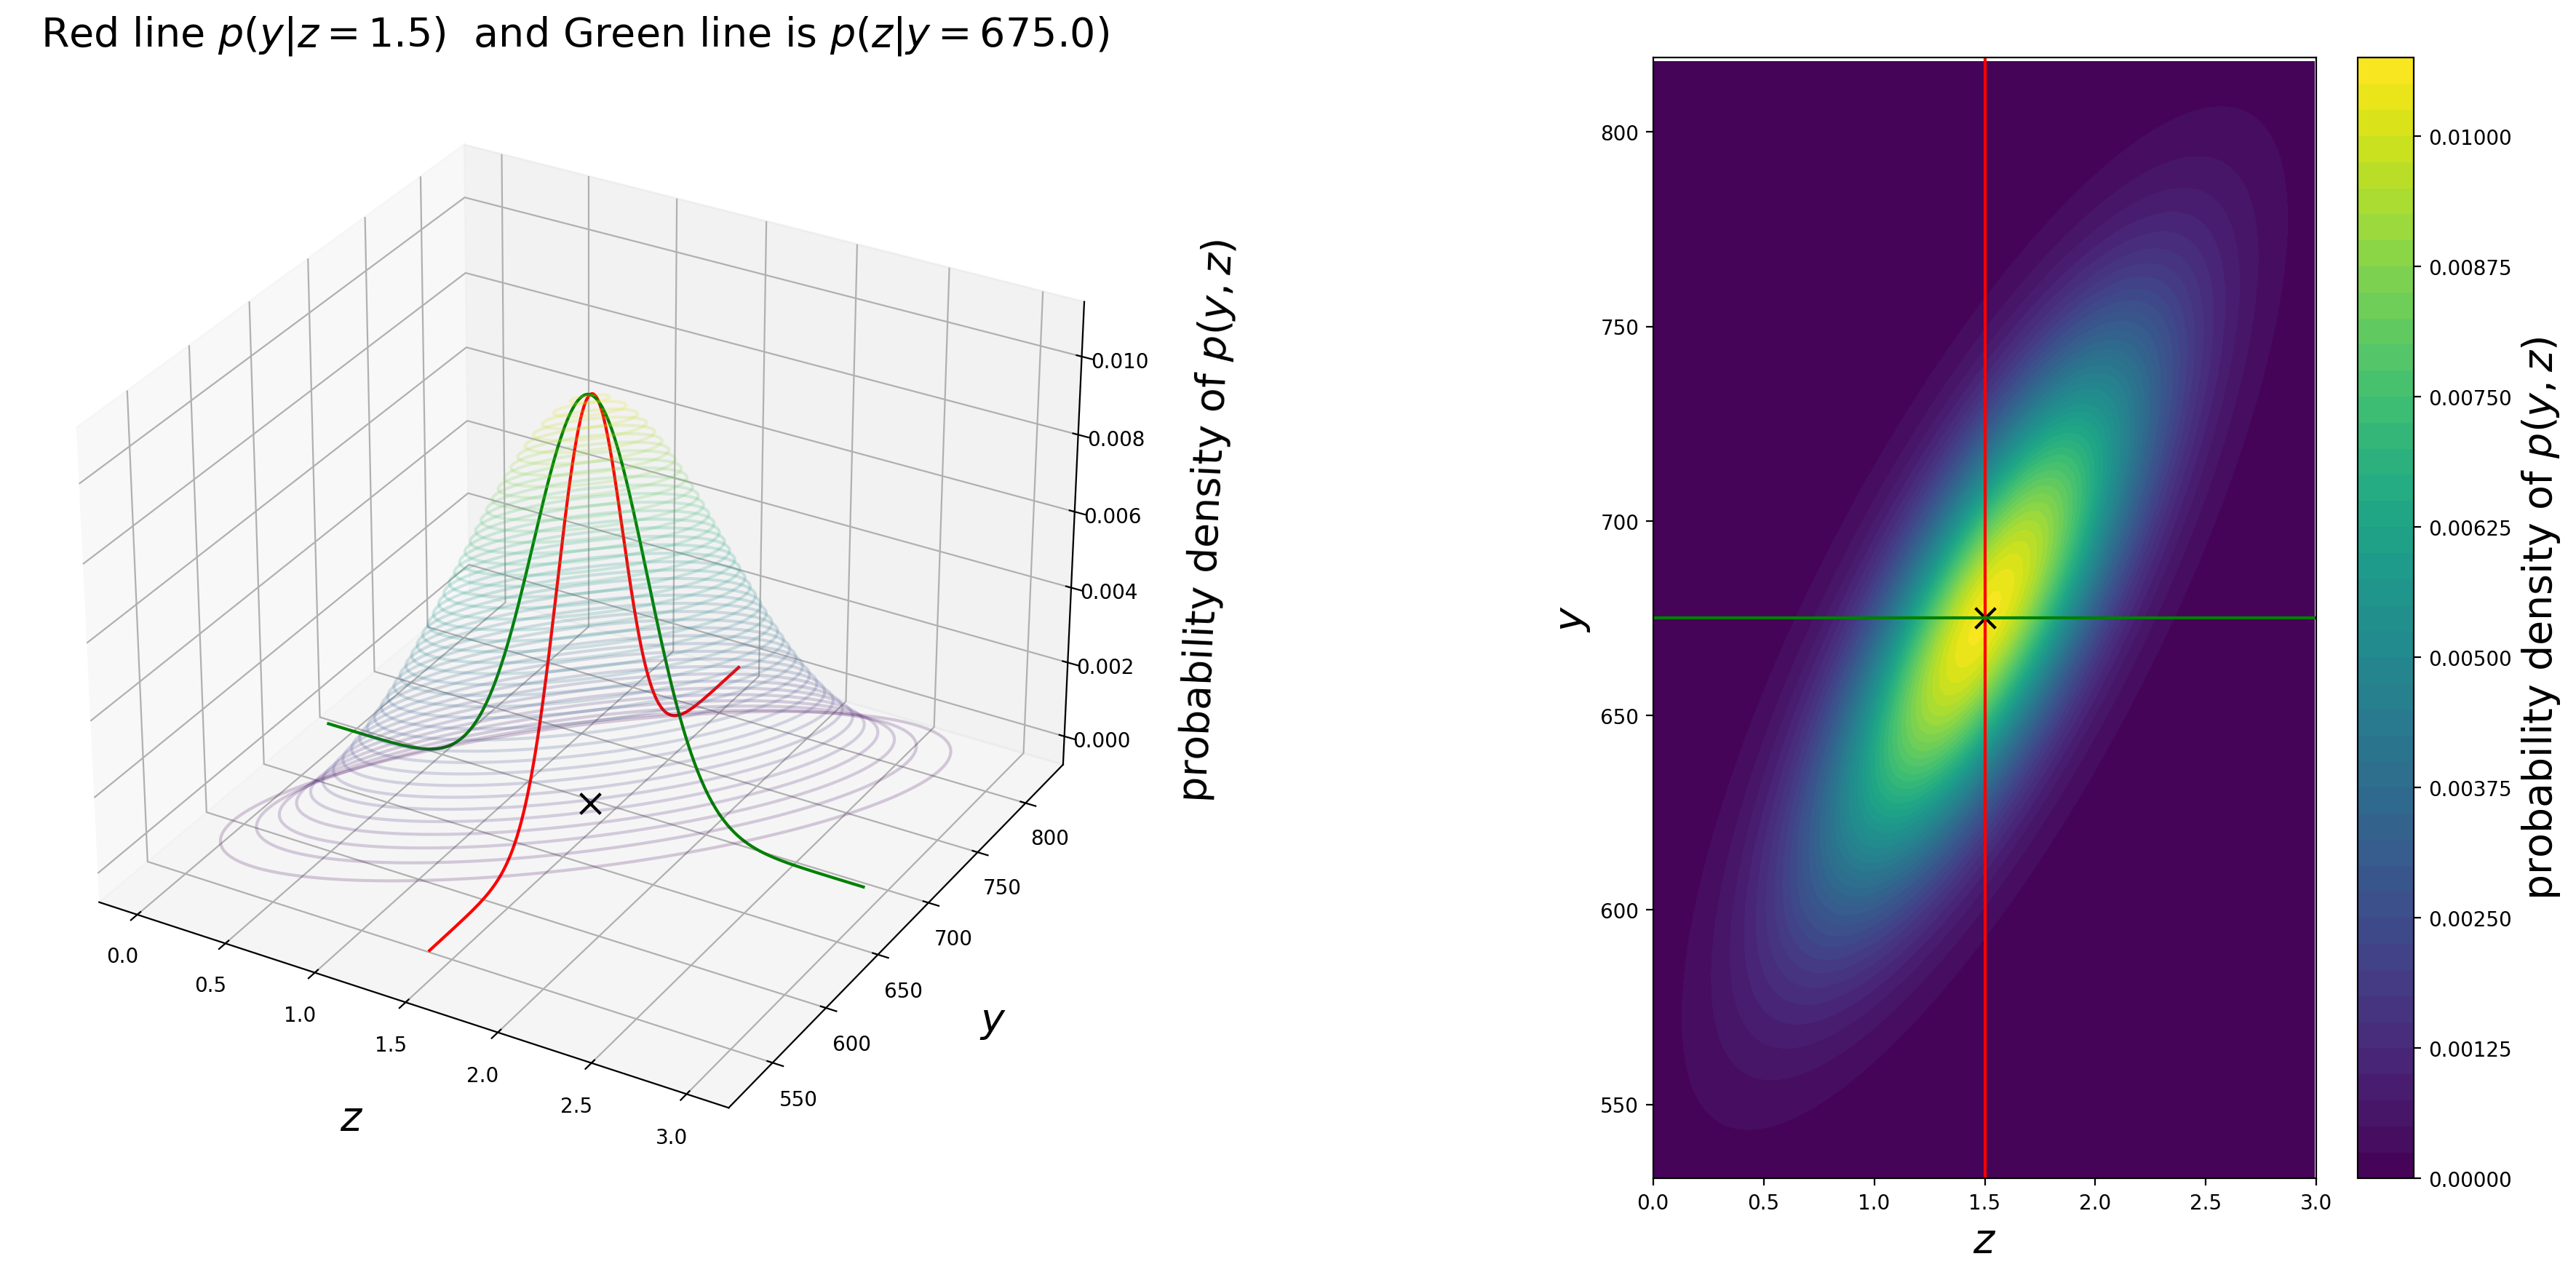

In [14]:
# Static plot (I skip this cell in presentations, but use it when printing slides to PDF)
fig2_joint_pdf_new(y_value=mu_y,z_value=mu_z)

In [15]:
# Same joint pdf but clarifying conditional pdf's with interactive plot. Code is hidden in presentation.
from ipywidgets import interactive # so that we can interact with the plot
interactive_plot = interactive(fig2_joint_pdf_new,
                               y_value=(y_grid_min, y_grid_max, (y_grid_max-y_grid_min)/10 ),
                               z_value=(z_grid_min, z_grid_max, (z_grid_max-z_grid_min)/10 ) )
interactive_plot

interactive(children=(FloatSlider(value=675.0, description='y_value', max=819.0702953422391, min=530.929704657…

### Q2. When we condition a joint Gaussian distribution on observed values, the result is...

In [16]:
from IPython.display import IFrame, display, HTML
display(HTML('''<div style="display: flex; align-items: flex-start; gap: 20px;">
    <div style="text-align: center;"> <img src="figures/slido_qr_code.png" width="200">
    <p><b>Scan to answer</b></p> </div>
    <iframe src="https://app.sli.do/event/vMxC77fHSUt38s6Dx6hgKG" width="1200" height="650"
    frameBorder="0" allow="clipboard-write"></iframe> </div>'''))

## Conclusions about Gaussian distributions

Our empirical investigations in this Lecture, have led to some interesting observations! They can be generalized to:
* If two sets of variables are jointly Gaussian, i.e. if their joint pdf is an MVN, then:
    * their conditional pdfs are Gaussian, i.e. the conditional distribution of one set conditioned on the other is again Gaussian!
    * the marginal distribution of either set is also Gaussian!

<font color='blue'>This is really important because it means that Gaussians are closed under Bayesian conditioning!</font> We will explore this later.

We'll apply multivariate Gaussians extensively in Lecture 2 (regression). For now, let's return to the univariate case and see how practitioners often simplify Bayesian inference...

# Part III: Machine learning without going Bayesian: point estimates

* Parameter estimation from training with data (model fitting)
    - Posterior approximation by Dirac delta "distribution"
    - Point estimates for the Dirac delta "distribution"
        * MAP: Maximum A Posteriori estimate
        * MLE: Maximum Likelihood Estimation 
    - Negative log likelihood (NLL) 
* Why some people do not adopt a Bayesian (probabilistic) perspective of ML

Machine Learning without going fully Bayesian means that we want to **completely avoid integration**.

This is possible by noting that:

1. Computing the PPD is trivial if the **posterior distribution becomes the Dirac delta**


2. The marginal likelihood is just a **constant**

Let's explore these two remarks.

### 1. PPD when the posterior is a Dirac delta

$$\require{color}
{\color{orange}p(y^*|\mathcal{D}_y)} = \int \underbrace{p(y^*|z)}_{\text{observation}\\ \text{distribution}} \overbrace{p(z|y=\mathcal{D}_y)}^{\text{posterior}} dz
$$

where $y^*$ signals that this is a prediction of $y$ (to help distinguish from training data).

What happens if the posterior is the Dirac delta "distribution"?

$$
p(z|y=\mathcal{D}_y) = \delta(z-\hat{z})
$$

where $\hat{z}$ is our best estimate for the value that $z$ should have.

$$\require{color}
\begin{align}
{\color{orange}p(y^*|\mathcal{D}_y)} &= \int \underbrace{p(y^*|z)}_{\text{observation}\\ \text{distribution}} \overbrace{p(z|y=\mathcal{D}_y)}^{\text{posterior}} dz\\
&= \int p(y^*|z) \delta(z-\hat{z}) dz \\
&= p(y^*|z=\hat{z})
\end{align}
$$

**Conclusion**: The PPD becomes the **observation distribution** where the unknown $z$ becomes our **best estimate** $\hat{z}$ (in other words: $z = \hat{z} =$ const)

* But what is our "**best estimate**" $\hat{z}$?
    - There are different estimates and different strategies to get there!

### 2. Finding the "best estimate" $\hat{z}$ without computing the marginal likelihood

Remember: the Bayes' rule determines the <font color='green'>posterior</font>,

$\require{color}$
$$
{\color{green}p(z|y=\mathcal{D}_y)} = \frac{ {\color{blue}p(y=\mathcal{D}_y|z)}{\color{red}p(z)} } {p(y=\mathcal{D}_y)}
$$

and the marginal likelihood $p(y=\mathcal{D}_y)$ is just a constant.

If we want to reduce the <font color='green'>posterior</font> to the Dirac delta "distribution",

$$
p(z|y=\mathcal{D}_y) = \delta(z-\hat{z})
$$

what is the only parameter that we need to find?

* We just need to find $\hat{z}$ to completely characterize $\delta(z-\hat{z})$

Note that this is not the case if the <font color='green'>posterior</font> is a different distribution!

* For example, **Part I** showed the posterior for the car stopping distance problem is a **Gaussian** when using a Gaussian likelihood and the noninformative Uniform prior $p(z) = \frac{1}{C_z}$:

$$\require{color}\begin{align}
{\color{green}p(z|y=\mathcal{D}_y)}
&= \mathcal{N}(z|\mu, \sigma^2)
\end{align}
$$

* If we were to solve the same problem for the same likelihood but now using a Gaussian prior $p(z) = \mathcal{N}\left(z| \overset{\scriptscriptstyle <}{\mu}_z, \overset{\scriptscriptstyle <}{\sigma}_z^2\right)$ (I do this in Lecture 7 of my course):

$$\require{color}\begin{align}
{\color{green}p(z|y=\mathcal{D}_y)} &= \mathcal{N}\left(z| \overset{\scriptscriptstyle >}{\mu}_z, \overset{\scriptscriptstyle >}{\sigma}_z^2\right) = \mathcal{N}\left(z\left|\frac{1}{\frac{1}{\sigma^2} + \frac{1}{\overset{\scriptscriptstyle <}{\sigma}_z^2}} \left( \frac{\mu}{\sigma^2} + \frac{\overset{\scriptscriptstyle <}{\mu}_z}{\overset{\scriptscriptstyle <}{\sigma}_z^2}\right), \frac{1}{\frac{1}{\sigma^2} + \frac{1}{\overset{\scriptscriptstyle <}{\sigma}_z^2}}\right.\right)
\end{align}
$$

The posterior is still a Gaussian but its mean and variance have been updated by the influence of the prior.

Let's play a simple game:
* Choose where to place the Dirac delta "distribution" for those two posteriors we found before.

In [17]:
# This cell is hidden during the presentation
from scipy.stats import norm # import the normal dist, as we learned before!
def samples_y(N_samples,x): # observations/measurements/samples for car stop. dist. prob. with 2 rv's
    mu_z = 1.5; sigma_z = 0.5;
    samples_z = norm.rvs(mu_z, sigma_z, size=N_samples) # randomly draw samples from the normal dist.
    samples_y = samples_z*x + 0.1*x**2 # compute the stopping distance for samples of z_1 and z_2
    return samples_y # return samples of y

In [18]:
# This cell is hidden during the presentation

# -------------------------------------------------------------------------------
# PARAMETERS YOU CAN CHANGE! PLAY A BIT WITH THIS ;)
x = 75 # keeping the car velocity constant at 75 m/s as we have done before
N_samples = 3 # Let's say our data is composed of 3 samples (empirical observations)
mu_prior_z = 3; sigma_prior_z = 2 # parameters of the Gaussian prior distribution (used only in case 2)
# -------------------------------------------------------------------------------


empirical_y = samples_y(N_samples, x) # Our data (empirical measurements of N_samples at x=75)

# Compute all the constants needed to plot the posterior for Lecture 6 and for Lecture 7
w = x
b = 0.1*x**2
sigma_yGIVENz = 80 # sigma_y|z (assumed value)
# Empirical mean and std directly calculated from observations:
empirical_mu_y = np.mean(empirical_y); empirical_sigma_y = np.std(empirical_y);
#
# Parameters of the likelihood function (not a distribution because it is not normalized):
sigma = np.sqrt(sigma_yGIVENz**2/(w**2*N_samples)) # std arising from the likelihood
mu = empirical_mu_y/w - b/w # mean arising from the likelihood (product of Gaussian densities for the data)
# -------------------------------------------------------------------------------
# Case 1: using a noninformative Uniform prior (Lecture 6):
# Posterior parameters:
#    These parameters are obvious in this case but I just want to highlight that the mean and std of this posterior
#    are the same as the parameters of the likelihood because posterior = likelihood / const )
sigma_posterior_UniformPrior = sigma # std of posterior (same as likelihood)
mu_posterior_UniformPrior = mu # mean of posterior (same as likelihood)
#
# PPD parameters:
PPD_mu_y_UniformPrior = mu*w + b # same result if using: np.mean(empirical_y)
PPD_sigma_y_UniformPrior = np.sqrt(w**2*sigma**2+sigma_yGIVENz**2) # same as: np.sqrt((80)**2*(1/N_samples + 1))

# z values for plot of case 1:
zrange_case1 = np.linspace(-3*sigma_posterior_UniformPrior+mu_posterior_UniformPrior,
                            3*sigma_posterior_UniformPrior+mu_posterior_UniformPrior, 200)
# Posterior values for plot of case 1:
posterior_pdf_values_case1 = norm.pdf(zrange_case1, mu, sigma)
# Probability density of posterior at the mean for case 1:
pdf_at_mean_case1 =  norm.pdf(mu_posterior_UniformPrior,mu_posterior_UniformPrior,sigma_posterior_UniformPrior)
# MAP estimate (maximum a posterior estimate) is the same as MLE (maximum likelihood estimation) for case 1:
pdf_at_mode_case1 = pdf_at_mean_case1 # in this case it's the same as mean (no calculation needed)
# -------------------------------------------------------------------------------
#
# -------------------------------------------------------------------------------
# CASE 2: using a Gaussian prior (Lecture 7):
# Posterior parameters:
sigma_posterior_GaussianPrior = np.sqrt( (sigma_prior_z**2*sigma**2)/(sigma_prior_z**2+sigma**2) )# std of posterior
mu_posterior_GaussianPrior = sigma_posterior_GaussianPrior**2*(mu/(sigma**2)+mu_prior_z/(sigma_prior_z**2)) # mean of posterior
# PPD parameters:
PPD_mu_y_GaussianPrior = mu_posterior_GaussianPrior*w + b
PPD_sigma_y_GaussianPrior = np.sqrt(w**2*sigma_posterior_GaussianPrior**2+sigma_yGIVENz**2)
#
# z values for plot:
zrange_case2 = np.linspace(-3*sigma_posterior_GaussianPrior+mu_posterior_GaussianPrior,
                            3*sigma_posterior_GaussianPrior+mu_posterior_GaussianPrior, 200)
# Posterior values for plot of case 2:
posterior_pdf_values_case2 = norm.pdf(zrange_case2, mu_posterior_GaussianPrior,
                                      sigma_posterior_GaussianPrior) # values of posterior for plotting
# Probability density of posterior at the mean for case 2:
pdf_at_mean_case2 = norm.pdf(mu_posterior_GaussianPrior,mu_posterior_GaussianPrior,sigma_posterior_GaussianPrior)
# MAP estimate (maximum a posterior estimate) for case 2:
pdf_at_mode_case2 = pdf_at_mean_case2 # in this case it's the same as mean (no calculation needed)
# -------------------------------------------------------------------------------


# Plot the posteriors that we calculate above and the Dirac delta at different z_hat
def Posteriors_and_Dirac_delta(z_hat_case1=mu_posterior_UniformPrior-2*sigma_posterior_UniformPrior,
                               z_hat_case2=mu_posterior_GaussianPrior-2*sigma_posterior_GaussianPrior):
    fig_Dirac, (ax_case1, ax_case2) = plt.subplots(1,2)
    #
    ax_case1.plot(zrange_case1, posterior_pdf_values_case1,
                  label=r"Posterior: $p(z|\mathcal{D}_y) = \mathcal{N}\left(z| \mu, \sigma^2\right)$")
    ax_case1.set_ylim(0, 1.3*pdf_at_mode_case1)
    ax_case1.plot(mu_posterior_UniformPrior, pdf_at_mean_case1,
                  'g^', markersize=25, linewidth=2,
                  label=r'mode: $\underset{z}{\mathrm{argmax}}\; p(z|\mathcal{D}_y)=\mu$')
    ax_case1.plot(mu_posterior_UniformPrior, pdf_at_mode_case1,
                  'k*', markersize=20, linewidth=2,
                  label=r'mean: $\mathbb{E}[z|\mathcal{D}_y]=\mu$')
    ax_case1.annotate("",
            xy=(z_hat_case1, 0), xycoords='data',
            xytext=(z_hat_case1, 1.3*pdf_at_mode_case1), textcoords='data',
            arrowprops=dict(arrowstyle="<-",
                            connectionstyle="arc3", color='r', lw=2),
            )
    ax_case1.text(z_hat_case1, pdf_at_mode_case1*1.05, 'Dirac $\delta$', rotation = -90, fontsize = 15)
    ax_case1.text(z_hat_case1, 0, ('$\hat{z}=%1.2f$' % z_hat_case1), fontsize = 15)
    ax_case1.set_xlabel("z", fontsize=20)
    ax_case1.set_ylabel("probability density", fontsize=20)
    ax_case1.legend(loc='center right', fontsize=12)
    ax_case1.set_title("Posterior using noninformative Uniform prior (Lecture 6)", fontsize=16)
    #
    ax_case2.plot(zrange_case2, posterior_pdf_values_case2,
                  label=r"Posterior: $p(z|\mathcal{D}_y) = \mathcal{N}\left(z| \overset{>}{\mu}_z, \overset{>}{\sigma}_z^2\right)$")

    ax_case2.set_ylim(0, 1.3*pdf_at_mode_case2)
    ax_case2.plot(mu_posterior_GaussianPrior, pdf_at_mean_case2,
                  'g^', markersize=25, linewidth=2,
                  label=r'mode: $\underset{z}{\mathrm{argmax}}\; p(z|\mathcal{D}_y)=\overset{>}{\mu}_z$')
    ax_case2.plot(mu_posterior_GaussianPrior, pdf_at_mean_case2,
                  'k*', markersize=20, linewidth=2,
                  label=r'mean: $\mathbb{E}[z|\mathcal{D}_y]=\overset{>}{\mu}_z$')
    ax_case2.annotate("",
            xy=(z_hat_case2, 0), xycoords='data',
            xytext=(z_hat_case2, 1.3*pdf_at_mode_case2), textcoords='data',
            arrowprops=dict(arrowstyle="<-",
                            connectionstyle="arc3", color='r', lw=2),
            )
    ax_case2.text(z_hat_case2, pdf_at_mode_case2*1.05, 'Dirac $\delta$', rotation = -90, fontsize = 15)
    ax_case2.text(z_hat_case2, 0, ('$\hat{z}=%1.2f$' % z_hat_case2), fontsize = 15)
    ax_case2.set_xlabel("z", fontsize=20)
    ax_case2.set_ylabel("probability density", fontsize=20)
    ax_case2.legend(loc='center right', fontsize=12)
    ax_case2.set_title("Posterior using Gaussian prior (Lecture 7)", fontsize=16)
    fig_Dirac.set_size_inches(15, 6) # scale figure to be wider (since there are 2 subplots)

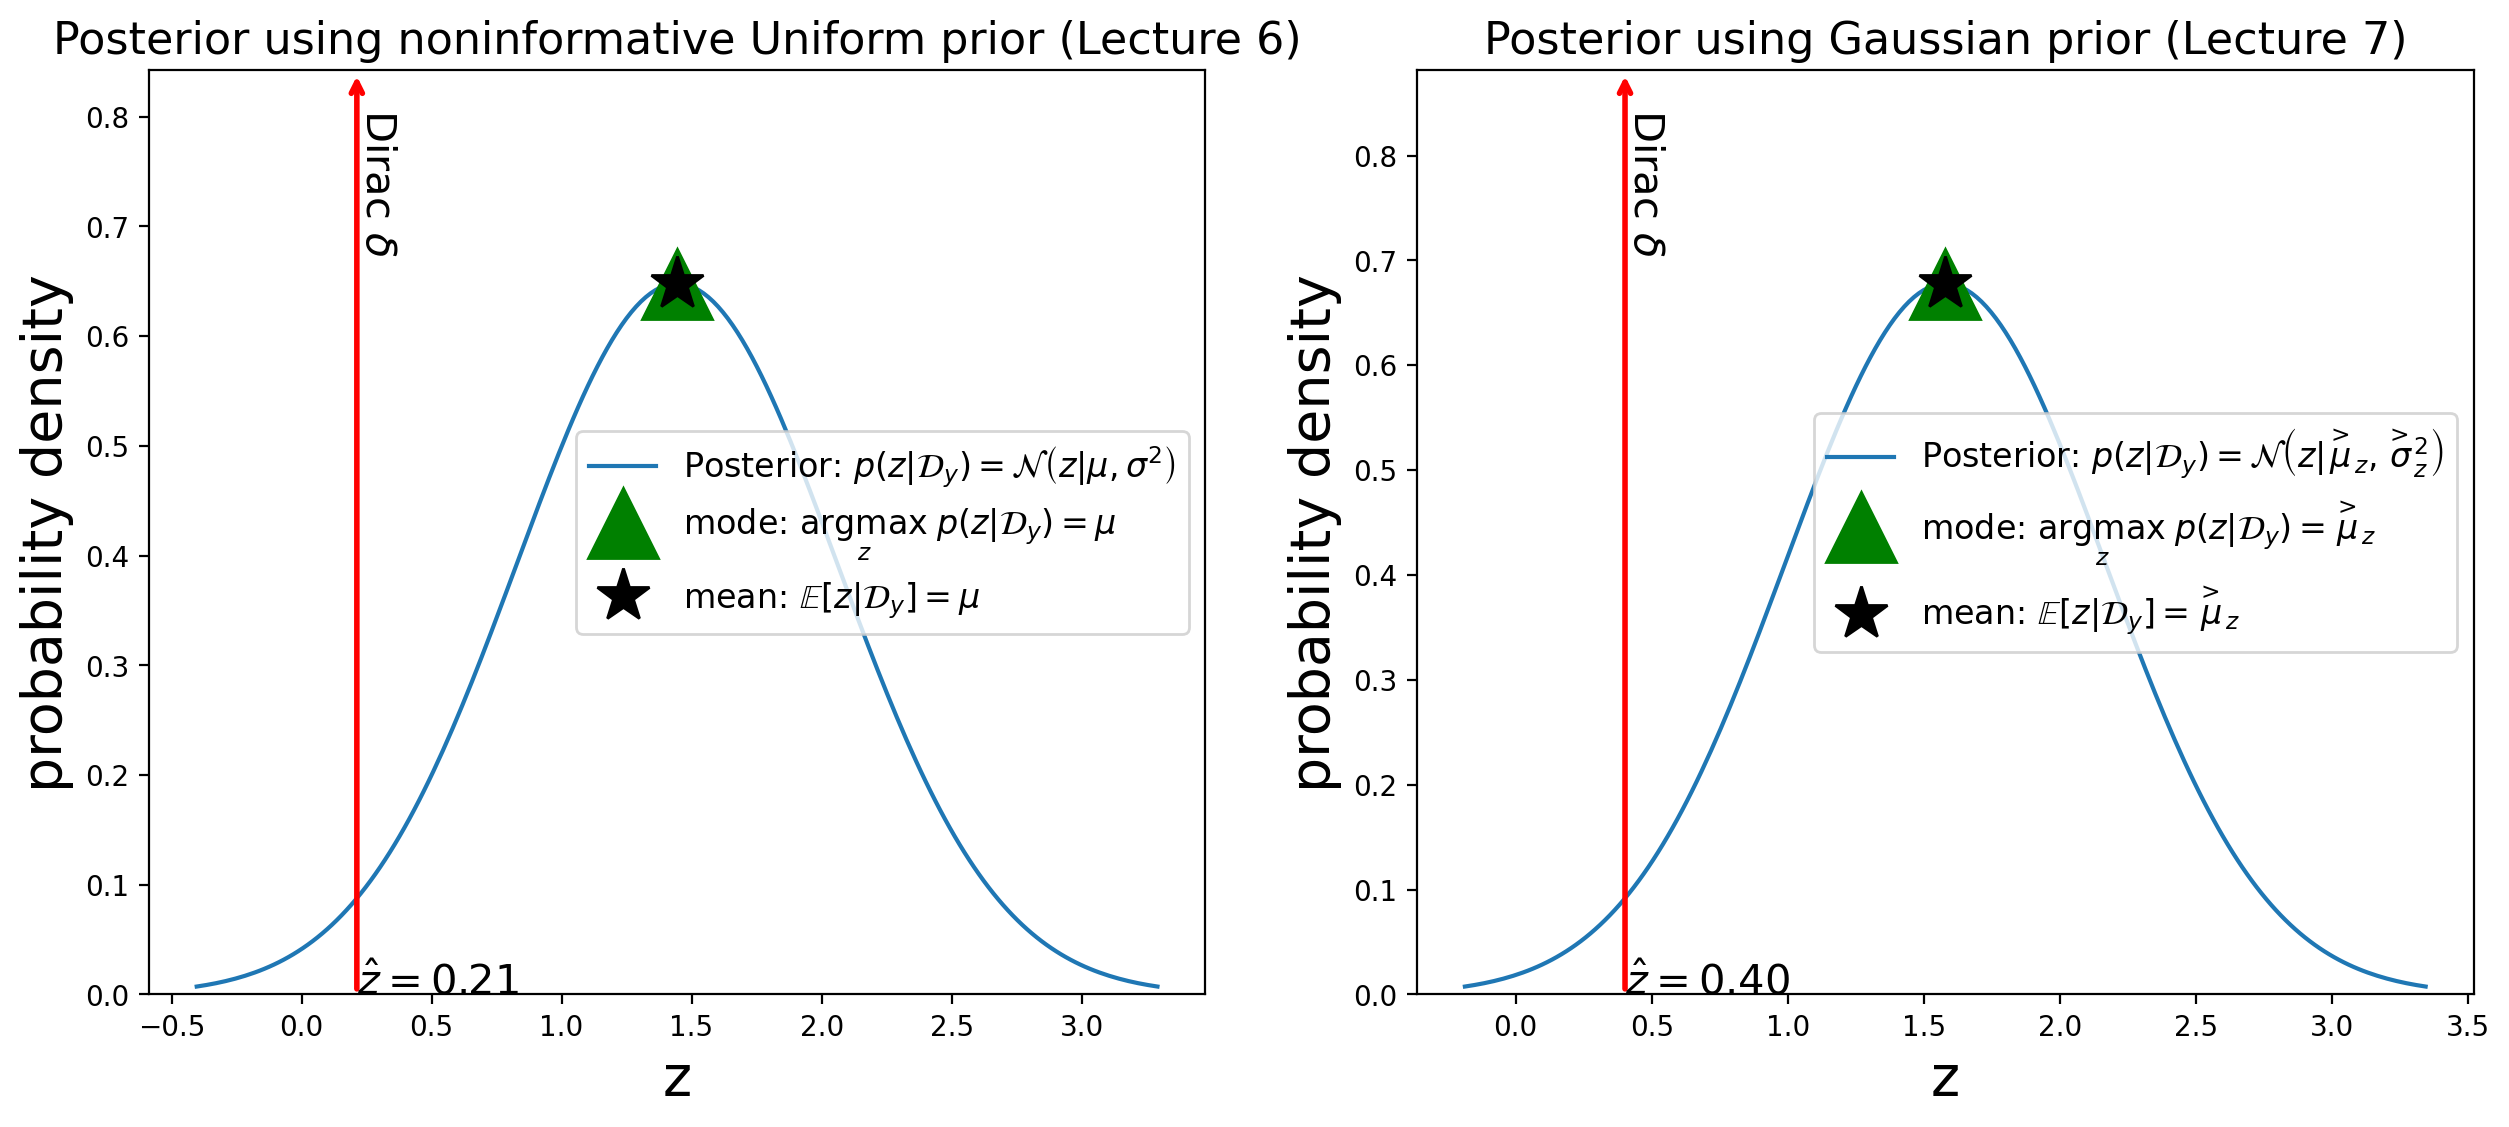

In [19]:
# Static plot (I skip this cell in presentations, but use it when printing slides to PDF)
Posteriors_and_Dirac_delta(z_hat_case1=mu_posterior_UniformPrior-2*sigma_posterior_UniformPrior,
                           z_hat_case2=mu_posterior_GaussianPrior-2*sigma_posterior_GaussianPrior)

In [20]:
# Showing posteriors and Dirac delta with interactive plot. Code is hidden in presentation.
from ipywidgets import interactive # so that we can interact with the plot
interactive_plot = interactive(Posteriors_and_Dirac_delta,
                       z_hat_case1=(min(zrange_case1), max(zrange_case1), 6/10*sigma_posterior_UniformPrior),
                       z_hat_case2=(min(zrange_case2), max(zrange_case2), 6/10*sigma_posterior_GaussianPrior) )
interactive_plot

interactive(children=(FloatSlider(value=0.2126660360505661, description='z_hat_case1', max=3.29186747172857, m…

Probably you didn't hesitate to place the Dirac delta "distribution" at the mean or mode (they are the same for a Gaussian distribution)!

What if the Posterior distribution is something else? For example, a Gamma distribution

In [21]:
# This cell is hidden during the presentation

# You may recall that we plotted the Gamma distribution in Lecture 1
# -------------------------------------------------------------------------------
# PARAMETERS YOU CAN CHANGE! PLAY A BIT WITH THIS ;)
x = 75 # keeping the car velocity constant at 75 m/s as we have done before
N_samples = 3 # Let's say our data is composed of 3 samples (empirical observations)
mu_prior_z = 3; sigma_prior_z = 2 # parameters of the Gaussian prior distribution (used only in case 2)
# -------------------------------------------------------------------------------

from scipy.stats import gamma # import from scipy.stats the Gamma distribution
from scipy.optimize import minimize # import minimizer to calculate mode

a = 2.0 # this is the only input parameter needed for this distribution

# Define the support of the distribution (its domain) by using the
# inverse of the cdf (called ppf) to get the lowest z of the plot that
# corresponds to Pr = 0.01 and the highest z of the plot that corresponds
# to Pr = 0.99:
zrange_min = gamma.ppf(0.01, a)
zrange_max = gamma.ppf(0.99, a)
zrange = np.linspace(zrange_min, zrange_max, 200)

mu_posterior, var_posterior = gamma.stats(2.0, moments='mv') # This computes the mean and variance of the pdf

posterior_pdf_values = gamma.pdf(zrange, a)

pdf_at_mean = gamma.pdf(mu_posterior, a)

# Finding the maximum of a function can be done by minimizing
# the negative gamma pdf. So, we create a function that outputs
# the negative of the gamma pdf given the parameter a=2.0:
def neg_gamma_given_a(z): return -gamma.pdf(z,a)

# Use the default optimizer of scipy (L-BFGS) to find the
# maximum (by minimizing the negative gamma pdf). Note
# that we need to give an initial guess for the value of z,
# so we can use, for example, z=mu_z:
mode_posterior = minimize(neg_gamma_given_a,mu_posterior).x # in general this is a vector, but for Gamma it's just a scalar

pdf_at_mode = gamma.pdf(mode_posterior, a) # in general this is a vector, but for Gamma is just a scalar

# Plot the posteriors that we calculate above and the Dirac delta at different z_hat
def Gamma_Posterior_and_Dirac_delta(z_hat=0.5):
    fig_Gamma, ax = plt.subplots()
    ax.plot(zrange, posterior_pdf_values, label=r"Posterior: $p(z|\mathcal{D}_y) = \Gamma(z|a)$")

    ax.plot(mu_posterior, pdf_at_mean, 'r*', markersize=15, linewidth=2,
            label=r'Posterior mean: $\mathbb{E}[z|\mathcal{D}_y]$')

    ax.plot(mode_posterior, pdf_at_mode[0],'g^', markersize=15,
            linewidth=2,label=r'Posterior mode: $\underset{z}{\mathrm{argmax}}\; p(z|\mathcal{D}_y)$')
    ax.annotate("",
            xy=(z_hat, 0), xycoords='data',
            xytext=(z_hat, 1.3*pdf_at_mode[0]), textcoords='data',
            arrowprops=dict(arrowstyle="<-",
                            connectionstyle="arc3", color='r', lw=2),
            )
    ax.text(z_hat, pdf_at_mode[0]*1.05, 'Dirac $\delta$', rotation = -90, fontsize = 15)
    ax.text(z_hat, 0, ('$\hat{z}=%1.2f$' % z_hat) , fontsize = 15)
    ax.set_ylim(0, 1.3*pdf_at_mode[0])
    ax.set_xlabel("z", fontsize=20)
    ax.set_ylabel("probability density", fontsize=20)
    ax.legend(loc='upper right', fontsize=15)
    ax.set_title("Posterior being a Gamma pdf for $a=2.0$", fontsize=20)
    fig_Gamma.set_size_inches(7.5, 6) # scale figure to be wider (since there are 2 subplots)

In [22]:
# Showing posteriors and Dirac delta with interactive plot. Code is hidden in presentation.
interactive_plot = interactive(Gamma_Posterior_and_Dirac_delta,z_hat=(0.5, 6.5, 0.5 ) )
interactive_plot

interactive(children=(FloatSlider(value=0.5, description='z_hat', max=6.5, min=0.5, step=0.5), Output()), _dom…

Maybe now you are hesitating where to place it?

Both are used in practice! And there are other estimates...

These are called **point estimates**.

* They reduce each unknown rv $z$ to a point $\hat{z}$ (transforming the posterior distribution into the Dirac delta "distribution").

Of course, as everything in life, some choices are better than others...

Common point estimates for determining $\hat{z}$:
* Maximum Likelihood Estimation (MLE):
    - You choose the mode (the maximum) of the posterior but you used a Uniform prior
* Maximum A Posteriori (MAP) estimate:
    - You choose the mode (the maximum) of the posterior (and your prior is **not** Uniform)
* Posterior mean estimate (no accronym!):
    - You choose the mean of the posterior.
* ... and so on

Calculating the **Posterior mean estimate** is not new to us:

$$
\mathbb{E}[z|\mathcal{D}]= \int_{\mathcal{Z}}z p(z|\mathcal{D}) dz
$$

But I told you that today we are all about avoiding integrals!

So, let's focus on two very common point estimates: **MAP** and **MLE**.

Both are obtained by finding the **mode** of the <font color='green'>posterior</font> (i.e. maximum location in the posterior):

$$
\require{color}\hat{\mathbf{z}} = \underset{z}{\mathrm{argmax}}\; {\color{green}p(z|\mathcal{D})}
$$

In other words, we need to solve an optimization problem.

But finding the mode of the posterior involves a few simple "tricks"...

$$\require{color}
{\color{green}p(z|y=\mathcal{D}_y)} = \frac{ {\color{blue}p(y=\mathcal{D}_y|z)}{\color{red}p(z)} } {p(y=\mathcal{D}_y)}
$$

#### Calculating the mode of posterior: Trick 1 (taking the $\log$)

We can separate the three terms of the <font color='green'>posterior</font> if we work with its $\log$:

$$
\log{{\color{green}p(z|y=\mathcal{D}_y)}} = \log{{\color{blue}p(y=\mathcal{D}_y|z)}} + \log{{\color{red}p(z)}} - \log{p(y=\mathcal{D}_y)}
$$

* Note: $\log$ is a monotone function, so the $\mathrm{argmax}$ of a function is the same as the $\mathrm{argmax}$ of the $\log$ of the function! Mathematically:

$$
\require{color}\hat{\mathbf{z}} = \underset{z}{\mathrm{argmax}}\; {\color{green}p(z|\mathcal{D})} = \underset{z}{\mathrm{argmax}}\; \log{{\color{green}p(z|\mathcal{D})}}
$$

#### Calculating the mode: Trick 2 (maximizing by minimizing the negative $\log$)

**Maximizing a function** is the same as **minimizing the negative of a function** (flipping the sign in the end).

Mathematically:

$$
\require{color}\hat{\mathbf{z}} = \underset{z}{\mathrm{argmax}}\; \log{{\color{green}p(z|\mathcal{D})}} = \underset{z}{\mathrm{argmin}} \left[-\log{{\color{green}p(z|\mathcal{D})}}\right]
$$

* In numerical optimization, this is very common practice!
    - Most optimization algorithms are designed to *minimize* functions.
    - In general, when we are optimizing (whether maximizing or minimizing) functions we call them "**objective**" functions. Yet, in particular:
        * when we are *minimizing* functions we call them "**loss**" or "cost" functions.
        * when we are *maximizing* functions we call them "**reward**" or "score" functions.

#### Calculating the mode: focusing on each $\log$ term

$$\require{color}
\begin{align}
\hat{\mathbf{z}} &= \underset{z}{\mathrm{argmax}}\left[\log{{\color{green}p(z|y=\mathcal{D}_y)}}\right] \\
&= \underset{z}{\mathrm{argmin}}\left[-\log{{\color{green}p(z|y=\mathcal{D}_y)}}\right] \\
&= \underset{z}{\mathrm{argmin}}\left[-\log{{\color{blue}p(y=\mathcal{D}_y|z)}} - \log{{\color{red}p(z)}} + \log{p(y=\mathcal{D}_y)}\right]\\
&= \underset{z}{\mathrm{argmin}}\left[-\log{{\color{blue}p(y=\mathcal{D}_y|z)}} - \log{{\color{red}p(z)}}+\text{constant}\right]\\
\end{align}
$$

* The last line can be further simplified because a constant does not change the location of the minimum.

So, we get: $\require{color}
\hat{\mathbf{z}} = \underset{z}{\mathrm{argmin}}\left[-\log{{\color{blue}p(y=\mathcal{D}_y|z)}} - \log{{\color{red}p(z)}}\right]$

At this point, recall that the <font color='blue'>likelihood</font> is usually calculated assuming the training examples (observations) are sampled independently from the observation distribution $p(y|z)$:

$$
p(y=\mathcal{D}_y | z) = \prod_{i=1}^{N} p(y=y_i|z)
$$

which is known as the **i.i.d.** assumption (independent and identically distributed).

This means that the $\log$ likelihood usually has a very convenient form:

$$
\mathrm{LL}(z) = \log{{\color{blue}p(y=\mathcal{D}_y|z)}} = \sum_{i=1}^{N} \log{p(y=y_i|z)}
$$

which decomposed into a sum of terms, one per example (observation).

**In summary**, the mode of the posterior is calculated as:

$\require{color}
\hat{\mathbf{z}} = \underset{z}{\mathrm{argmin}}\left[-\log{{\color{blue}p(y=\mathcal{D}_y|z)}} - \log{{\color{red}p(z)}}\right]$

where the first term is called **negative log likelihood**:

$\mathrm{NLL}(z) = -\mathrm{LL}(z) = -\log{{\color{blue}p(y=\mathcal{D}_y|z)}}=-\sum_{i=1}^{N} \log{p(y=y_i|z)}$

#### Maximum A Posterior (MAP) estimate

If we choose any <font color='red'>prior</font> distribution **except** the Uniform distribution, then the estimate is called MAP:

$\require{color}
\hat{\mathbf{z}}_{\text{map}} = \underset{z}{\mathrm{argmin}}\left[-\log{{\color{blue}p(y=\mathcal{D}_y|z)}} - \log{{\color{red}p(z)}}\right]$

where $p(z)$ is **not** the Uniform distribution.

#### Maximum Likelihood Estimation (MLE)

In the special case of choosing the prior to be a **Uniform distribution**, $p(z) \propto 1$, then the mode of the posterior becomes the same as the mode of the (log) likelihood:

$$\require{color}
\hat{\mathbf{z}} = \underset{z}{\mathrm{argmin}}\left[-\log{{\color{blue}p(y=\mathcal{D}_y|z)}} - \log{{\color{red}p(z)}}\right] = \underset{z}{\mathrm{argmin}}\left[-\log{{\color{blue}p(y=\mathcal{D}_y|z)}}\right]
$$

and we say that we are using the Maximum Likelihood Estimation (MLE) for the unknown $z$:

$$
\hat{\mathbf{z}}_{\text{mle}} = \underset{z}{\mathrm{argmin}}\left[-\log{{\color{blue}p(y=\mathcal{D}_y|z)}}\right] = \underset{z}{\mathrm{argmin}}\left[-\sum_{i=1}^{N}\log{ p(y=y_i|z)}\right]
$$

where, again, the argument of this expression is called the **negative log likelihood** $\mathrm{NLL}(z)$.

### Q3. MLE is equivalent to MAP when...

In [23]:
from IPython.display import IFrame, display, HTML
display(HTML('''<div style="display: flex; align-items: flex-start; gap: 20px;">
    <div style="text-align: center;"> <img src="figures/slido_qr_code.png" width="200">
    <p><b>Scan to answer</b></p> </div>
    <iframe src="https://app.sli.do/event/vMxC77fHSUt38s6Dx6hgKG" width="1200" height="650"
    frameBorder="0" allow="clipboard-write"></iframe> </div>'''))

## Summary of Machine Learning without going fully Bayesian

1. Approximate posterior by a **Dirac delta** "distribution" $\delta(z-\hat{z})$ where $\hat{z}$ is a chosen **Point estimate**:
    * MLE: $\hat{\mathbf{z}}_{\text{mle}} = \underset{z}{\mathrm{argmin}}\left[-\sum_{i=1}^{N}\log{ p(y=y_i|z)}\right]$
    * MAP: $\hat{\mathbf{z}}_{\text{map}} = \underset{z}{\mathrm{argmin}}\left[-\sum_{i=1}^{N}\log{ p(y=y_i|z)}- \log{p(z)}\right] $
    * etc.


2. Compute the <font color='orange'>PPD</font> using the Point estimate $\hat{z}$ and without calculating any integrals:
$$\require{color}
{\color{orange}p(y^*|\mathcal{D}_y)} = \int p(y^*|z) \delta(z-\hat{z}) dz = p(y^*|z=\hat{z})
$$

## A reflection on Bayesian versus non-Bayesian perspective on ML

We can do one last simplification (but it can **mislead** us into believing that ML is not probabilistic!)

When the <font color='orange'>PPD</font> is approximated by the observation distribution for a Point estimate $\hat{z}$, allowing us to predict for new points $y^*$:

$$\require{color}
{\color{orange}p(y^*|\mathcal{D}_y)} = p(y^*|z=\hat{z})
$$

we can decide to focus on only making a prediction for the **mean** of the PPD and even forget that it is a distribution (we forget uncertainties!).

This is very common in ML literature!

## Key Takeaways from Lecture 1

**Part I: Bayesian Machine Learning**
- A probabilistic model = **observation distribution** $p(y|z)$ + **prior** $p(z)$
- Bayes' rule gives us the **posterior**: $p(z|\mathcal{D}) \propto p(\mathcal{D}|z) \cdot p(z)$
- The **likelihood** summarizes all the information from observed data

**Part II: From Posterior to Predictions**
- The **Posterior Predictive Distribution (PPD)** is what we really want for predictions
- The **covariance matrix** captures relationships between variables
- Gaussians are **closed under conditioning**: if joint is Gaussian, conditional is Gaussian

**Part III: Point Estimates**
- Approximate posterior as **Dirac delta** → avoid integration
- **MLE**: maximize likelihood (uniform prior)
- **MAP**: maximize posterior (informative prior)
- Most "non-Bayesian" ML is actually Bayesian with these simplifications!

## End of Lecture 1

### Full course references for deeper understanding:

| Topic | Full Course Lecture |
|-------|--------------------|
| Random variables, Gaussian pdf | Lecture 1 |
| Data handling, supervised learning | Lecture 2 |
| Joint, marginal, conditional pdfs | Lecture 3 |
| Multivariate Gaussian | Lecture 4 |
| Bayesian inference (uniform prior) | Lecture 5 |
| Posterior Predictive Distribution | Lecture 6 |
| Bayesian inference (Gaussian prior) | Lecture 7 |
| MAP and MLE point estimates | Lecture 8 |